# MAS Edge Performance & Prediction Analysis
### `mas-single` · FPS 10.0 · 2026-06-18

This notebook performs a comprehensive analysis of the multi-agent system (MAS) execution log, integrating:
- **Capture pipeline metrics** from `metrics.json` (frames, suited frames, lead time, latency)
- **System resource telemetry** from `cpu.csv`, `mem.csv`, `temp.csv`
- **Prediction quality report** from `report.md` (absolute/relative error, selector F1-score)

The central question is the **FPS → suited frames → prediction error → resource impact** tradeoff on the edge device.


## 0. Setup & Data Loading

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

warnings.filterwarnings("ignore")

# ── Aesthetics ──────────────────────────────────────────────────────────────
PALETTE   = ["#2B7BB9", "#E8593C", "#2CA02C", "#9467BD", "#8C564B", "#F7B731"]
ACCENT    = "#2B7BB9"
WARN      = "#E8593C"
OK_GREEN  = "#2CA02C"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titleweight":   "bold",
    "axes.titlesize":     13,
    "figure.facecolor":   "white",
})

# ── Folder path (edit for local / Colab) ────────────────────────────────────
# OPTION A – Local path (edit to your directory)
folder_path = "/Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T16:53:49.862882"

# OPTION B – Google Colab upload (uncomment block below)
# try:
#     from google.colab import files
#     import shutil
#     print("Upload metrics.json, cpu.csv, mem.csv, temp.csv:")
#     uploaded = files.upload()
#     cloud_dir = "/content/metrics_logs"
#     os.makedirs(cloud_dir, exist_ok=True)
#     for fn in uploaded:
#         shutil.move(fn, os.path.join(cloud_dir, fn))
#     folder_path = cloud_dir
# except ImportError:
#     pass

print(f"📂 folder_path = {folder_path}")


📂 folder_path = /Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T16:53:49.862882


In [3]:
# ── Load metrics.json ───────────────────────────────────────────────────────
with open(os.path.join(folder_path, "metrics.json")) as f:
    raw = json.load(f)

load_model_dur = (
    datetime.fromisoformat(raw["load_model_final"]) -
    datetime.fromisoformat(raw["load_model_start"])
).total_seconds()

print(f"PID              : {raw.get('pid', 'N/A')}")
print(f"Model load time  : {load_model_dur*1000:.1f} ms")
print(f"Animals in JSON  : {len(raw['animals'])}")


PID              : mas-single_2026-06-18T16:53:49.862882
Model load time  : 43.1 ms
Animals in JSON  : 189


In [4]:
# ── Parse per-animal records from metrics.json ──────────────────────────────
rows_animals, rows_imgs = [], []

for animal_id, info in raw["animals"].items():
    first_cap  = datetime.fromisoformat(info["first_image_capture_time"])  if info.get("first_image_capture_time")  else None
    last_cap   = datetime.fromisoformat(info["last_image_capture_time"])   if info.get("last_image_capture_time")   else None
    pred_final = datetime.fromisoformat(info["weight_prediction_final"])   if info.get("weight_prediction_final")   else None

    lead_time = (pred_final - first_cap).total_seconds() if (pred_final and first_cap) else np.nan
    latency   = (pred_final - last_cap).total_seconds()  if (pred_final and last_cap)  else np.nan

    proc_delays = []
    for img_idx, img_info in info.get("imgs", {}).items():
        if "weight_prediction_start" in img_info and "weight_prediction_final" in img_info:
            t0 = datetime.fromisoformat(img_info["weight_prediction_start"])
            t1 = datetime.fromisoformat(img_info["weight_prediction_final"])
            dur = (t1 - t0).total_seconds()
            proc_delays.append(dur)
            rows_imgs.append({
                "animal_id":            animal_id,
                "image_index":          img_idx,
                "weight_prediction_start": t0,
                "weight_prediction_final": t1,
                "prediction_duration_sec": dur,
                "label":                img_info.get("label"),
            })

    rows_animals.append({
        "animal_id":                  animal_id,
        "first_image_capture_time":   first_cap,
        "last_image_capture_time":    last_cap,
        "weight_prediction_final":    pred_final,
        "total_of_images":            info.get("total_of_images", 0),
        "suitable_images":            info.get("suitable_images", 0),
        "by_animal_lead_time_sec":    lead_time,
        "by_animal_processing_delay_sec": sum(proc_delays) if proc_delays else 0.0,
        "by_animal_latency_sec":      latency,
        "n_inference_calls":          len(proc_delays),
    })

df_animals = pd.DataFrame(rows_animals)
df_imgs    = pd.DataFrame(rows_imgs)
print(f"df_animals shape : {df_animals.shape}")
print(f"df_imgs shape    : {df_imgs.shape}")


df_animals shape : (189, 10)
df_imgs shape    : (1770, 6)


In [5]:
# ── Load telemetry CSVs ──────────────────────────────────────────────────────
def load_csv_ts(fname):
    df = pd.read_csv(os.path.join(folder_path, fname))
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df.sort_values("timestamp").reset_index(drop=True)

df_cpu  = load_csv_ts("cpu.csv")
df_mem  = load_csv_ts("mem.csv")
df_temp = load_csv_ts("temp.csv")

core_cols = [c for c in df_cpu.columns if c.startswith("cpu_core_")]
df_cpu["cpu_mean"] = df_cpu[core_cols].mean(axis=1)
df_mem["ram_gb"]   = df_mem["used"] / 1e9

print(f"CPU  rows: {len(df_cpu):,}  |  cores: {len(core_cols)}")
print(f"MEM  rows: {len(df_mem):,}  |  total RAM: {df_mem['total'].iloc[0]/1e9:.1f} GB")
print(f"TEMP rows: {len(df_temp):,}  |  range: {df_temp['temperature'].min():.1f}–{df_temp['temperature'].max():.1f} °C")


CPU  rows: 1,475  |  cores: 4
MEM  rows: 1,478  |  total RAM: 17.0 GB
TEMP rows: 1,475  |  range: 50.1–74.3 °C


In [6]:
# ── Load report.md (ground-truth errors from evaluator) ─────────────────────
REPORT_DATA = """
animal_id,gt_weight,pred_weight,abs_error,rel_error_pct,total_frames,suited_pred,suited_gt,precision,recall,f1
0002,46.80,44.3586,2.4414,5.22,106,14,14,1.00,1.00,1.00
0005az,44.30,42.6440,1.6560,3.74,247,29,29,1.00,1.00,1.00
0006,47.90,45.4477,2.4523,5.12,168,5,7,1.00,0.71,0.83
000742,44.95,43.2224,1.7276,3.84,155,23,18,0.78,1.00,0.88
0007vm,44.70,43.9511,0.7489,1.68,118,8,10,1.00,0.80,0.89
0008vd,43.00,45.2378,2.2378,5.20,144,6,8,1.00,0.75,0.86
0008vm,38.80,39.0819,0.2819,0.73,81,4,4,1.00,1.00,1.00
0009ro,39.30,39.0591,0.2409,0.61,98,4,4,1.00,1.00,1.00
0009vd,43.00,38.3212,4.6788,10.88,89,3,3,1.00,1.00,1.00
0010,44.20,42.7194,1.4806,3.35,100,9,9,1.00,1.00,1.00
0010az,43.90,40.8208,3.0792,7.01,152,23,23,1.00,1.00,1.00
0011br,34.85,39.0348,4.1848,12.01,70,7,7,1.00,1.00,1.00
0013ro,37.90,40.8291,2.9291,7.73,114,9,9,1.00,1.00,1.00
0014,30.20,28.4542,1.7458,5.78,114,18,13,0.72,1.00,0.84
0014s2,30.20,37.9049,7.7049,25.51,83,7,6,0.86,1.00,0.92
0014vm,47.50,44.0130,3.4870,7.34,104,6,6,1.00,1.00,1.00
0015,35.10,36.2326,1.1326,3.23,102,6,6,1.00,1.00,1.00
0020,33.85,35.0006,1.1506,3.40,71,6,6,1.00,1.00,1.00
0020az,44.20,43.3978,0.8022,1.81,165,10,9,0.90,1.00,0.95
0020vd,43.60,39.1829,4.4171,10.13,109,3,3,1.00,1.00,1.00
0021,35.55,37.6518,2.1018,5.91,107,5,5,1.00,1.00,1.00
0024,41.15,39.6213,1.5287,3.71,164,29,27,0.93,1.00,0.96
0024br,17.75,16.1775,1.5725,8.86,86,8,8,1.00,1.00,1.00
0024vd,37.20,34.6048,2.5952,6.98,233,4,4,1.00,1.00,1.00
0026,42.40,40.8185,1.5815,3.73,89,11,11,1.00,1.00,1.00
0027vm,19.85,20.8422,0.9922,5.00,144,80,80,1.00,1.00,1.00
0028vm,16.85,15.0431,1.8069,10.72,89,16,16,1.00,1.00,1.00
0029,32.90,35.1032,2.2032,6.70,95,6,6,1.00,1.00,1.00
0029am,10.55,11.8088,1.2588,11.93,100,38,40,1.00,0.95,0.97
0030am,15.80,16.8877,1.0877,6.88,113,33,34,1.00,0.97,0.99
0031az,39.60,39.4290,0.1710,0.43,128,7,7,1.00,1.00,1.00
0032az,37.70,39.9459,2.2459,5.96,319,31,32,1.00,0.97,0.98
0034az,34.35,34.4617,0.1117,0.33,151,5,5,1.00,1.00,1.00
0035,29.85,30.3707,0.5207,1.74,71,7,7,1.00,1.00,1.00
0041vd,38.05,39.8970,1.8470,4.85,52,5,5,1.00,1.00,1.00
0041vds2,38.05,38.7671,0.7171,1.88,43,5,5,1.00,1.00,1.00
0043az,32.10,31.7528,0.3472,1.08,73,7,5,0.71,1.00,0.83
0044,30.85,30.4044,0.4456,1.44,68,4,4,1.00,1.00,1.00
0047,44.75,42.9179,1.8321,4.09,83,6,6,1.00,1.00,1.00
0047az,42.90,40.3150,2.5850,6.03,121,8,6,0.75,1.00,0.86
0048az,37.10,40.3815,3.2815,8.85,108,8,8,1.00,1.00,1.00
0050,33.35,32.4992,0.8508,2.55,98,6,6,1.00,1.00,1.00
0050vd,38.95,38.5795,0.3705,0.95,108,6,6,1.00,1.00,1.00
0052az,46.20,45.6353,0.5647,1.22,138,35,33,0.94,1.00,0.97
0053az,41.05,40.1331,0.9169,2.23,319,50,49,0.98,1.00,0.99
0054az,42.80,42.3290,0.4710,1.10,95,8,7,0.75,0.86,0.80
0055,45.00,44.0961,0.9039,2.01,68,3,3,1.00,1.00,1.00
0056,43.55,43.1717,0.3783,0.87,72,6,6,1.00,1.00,1.00
0057,42.50,40.4007,2.0993,4.94,172,17,15,0.88,1.00,0.94
0059,83.65,87.6565,4.0065,4.79,115,6,4,0.67,1.00,0.80
0059az,38.55,36.5129,2.0371,5.28,103,6,6,1.00,1.00,1.00
0060az,39.85,38.3285,1.5215,3.82,101,4,4,1.00,1.00,1.00
0062,42.30,42.1996,0.1004,0.24,221,4,5,1.00,0.80,0.89
0063vd,48.55,45.2970,3.2530,6.70,121,7,7,1.00,1.00,1.00
0065az,38.90,37.7794,1.1206,2.88,127,17,17,1.00,1.00,1.00
0065vd,32.75,32.8472,0.0972,0.30,115,14,14,1.00,1.00,1.00
0066az,43.60,41.1461,2.4539,5.63,132,19,19,1.00,1.00,1.00
0067vd,32.50,32.0566,0.4434,1.36,131,43,45,1.00,0.96,0.98
0068vd,40.04,39.4175,0.6225,1.55,450,50,54,0.96,0.89,0.92
0068vds2,40.04,39.5328,0.5072,1.27,376,132,127,0.95,0.98,0.97
0069az,41.20,38.3737,2.8263,6.86,191,6,5,0.83,1.00,0.91
0071az,48.50,46.6321,1.8679,3.85,73,3,3,1.00,1.00,1.00
0071vd,40.35,39.8347,0.5153,1.28,85,5,5,1.00,1.00,1.00
0074,47.90,41.8679,6.0321,12.59,87,10,8,0.80,1.00,0.89
0084az,45.60,44.9600,0.6400,1.40,89,5,6,1.00,0.83,0.91
0101,46.65,45.4037,1.2463,2.67,94,4,4,1.00,1.00,1.00
0116vd,22.05,20.0842,1.9658,8.92,70,6,6,1.00,1.00,1.00
0117vd,24.40,21.8667,2.5333,10.38,64,5,5,1.00,1.00,1.00
0118vd,24.35,22.6775,1.6725,6.87,76,14,14,1.00,1.00,1.00
0119vd,20.40,18.5798,1.8202,8.92,87,17,15,0.88,1.00,0.94
0120vd,11.60,11.2656,0.3344,2.88,118,31,33,1.00,0.94,0.97
0121vd,9.80,9.0292,0.7708,7.86,117,32,32,0.97,0.97,0.97
0122vd,12.50,14.8740,2.3740,18.99,103,4,4,1.00,1.00,1.00
0123vd,15.60,14.8383,0.7617,4.88,70,10,10,1.00,1.00,1.00
0124vd,13.65,13.2893,0.3607,2.64,65,6,8,1.00,0.75,0.86
0125vd,15.35,15.0532,0.2968,1.93,70,8,8,1.00,1.00,1.00
0126,43.30,38.0987,5.2013,12.01,131,9,7,0.78,1.00,0.88
0127vd,14.25,12.4174,1.8326,12.86,91,21,15,0.71,1.00,0.83
0128,35.00,36.1420,1.1420,3.26,154,11,12,1.00,0.92,0.96
0128vd,5.85,6.1880,0.3380,5.78,78,9,12,1.00,0.75,0.86
0129az,21.35,21.9629,0.6129,2.87,99,5,7,1.00,0.71,0.83
0130az,17.25,17.0137,0.2363,1.37,121,28,26,0.93,1.00,0.96
0131az,18.30,16.2027,2.0973,11.46,119,44,44,0.95,0.95,0.95
0133az,18.30,17.9722,0.3278,1.79,72,8,8,1.00,1.00,1.00
0134az,14.40,13.9759,0.4241,2.95,206,123,125,1.00,0.98,0.99
0135az,16.70,14.0919,2.6081,15.62,61,18,18,1.00,1.00,1.00
0137az,12.80,12.1083,0.6917,5.40,166,55,55,1.00,1.00,1.00
0138,53.15,45.0803,8.0697,15.18,133,11,9,0.82,1.00,0.90
0138azs2,11.40,14.9563,3.5563,31.20,68,6,6,1.00,1.00,1.00
0140qz,12.85,12.3972,0.4528,3.52,137,81,83,1.00,0.98,0.99
0141az,8.80,7.9091,0.8909,10.12,89,18,20,1.00,0.90,0.95
014bmf,18.60,17.2595,1.3405,7.21,94,19,19,1.00,1.00,1.00
0170,29.70,30.0486,0.3486,1.17,115,5,5,1.00,1.00,1.00
0182,33.70,51.1393,17.4393,51.75,147,1,3,1.00,0.33,0.50
0183,51.05,48.0768,2.9732,5.82,207,3,3,1.00,1.00,1.00
0184,33.30,31.7376,1.5624,4.69,116,14,14,1.00,1.00,1.00
0186,33.40,33.1467,0.2533,0.76,100,13,11,0.85,1.00,0.92
0188,29.65,30.5711,0.9211,3.11,90,5,6,1.00,0.83,0.91
0192,37.40,42.6947,5.2947,14.16,50,3,3,0.33,0.33,0.33
0197,43.80,42.8731,0.9269,2.12,120,6,3,0.50,1.00,0.67
01mf,16.75,16.5344,0.2156,1.29,144,89,88,0.99,1.00,0.99
0200,42.20,34.5384,7.6616,18.16,122,12,11,0.92,1.00,0.96
0210,43.55,41.1152,2.4348,5.59,94,5,5,1.00,1.00,1.00
0212,4.83,60.5456,55.7156,1153.53,73,3,3,1.00,1.00,1.00
0214,50.05,49.1960,0.8540,1.71,145,5,5,1.00,1.00,1.00
0217,43.50,44.6466,1.1466,2.64,145,4,4,1.00,1.00,1.00
0219,51.60,50.2986,1.3014,2.52,83,6,6,1.00,1.00,1.00
0247,46.20,43.9037,2.2963,4.97,151,34,32,0.94,1.00,0.97
0253,53.65,49.5725,4.0775,7.60,121,7,6,0.86,1.00,0.92
0262,51.95,50.3977,1.5523,2.99,259,22,22,1.00,1.00,1.00
0263,41.75,41.1325,0.6175,1.48,70,4,4,1.00,1.00,1.00
0275,58.15,55.1172,3.0328,5.22,146,5,3,0.60,1.00,0.75
0278,38.85,37.7461,1.1039,2.84,93,15,13,0.87,1.00,0.93
02mf,12.45,14.3393,1.8893,15.17,99,27,29,1.00,0.93,0.96
03mf,13.90,12.9750,0.9250,6.65,81,18,17,0.94,1.00,0.97
0428,39.20,38.4907,0.7093,1.81,92,9,8,0.89,1.00,0.94
0438,38.70,35.3313,3.3687,8.70,111,5,4,0.80,1.00,0.89
0456,33.70,42.9248,9.2248,27.37,122,7,5,0.71,1.00,0.83
0458,46.60,41.8661,4.7339,10.16,97,9,5,0.56,1.00,0.71
0463,44.65,43.3805,1.2695,2.84,187,5,3,0.60,1.00,0.75
0468,40.50,35.8136,4.6864,11.57,101,8,6,0.75,1.00,0.86
0472,41.70,40.4265,1.2735,3.05,154,4,4,1.00,1.00,1.00
0473,94.35,38.0377,56.3123,59.68,107,4,4,1.00,1.00,1.00
04mf,9.60,10.2047,0.6047,6.30,59,9,9,1.00,1.00,1.00
0502,15.50,12.7753,2.7247,17.58,99,12,12,1.00,1.00,1.00
0502vd,39.00,41.9804,2.9804,7.64,89,10,10,1.00,1.00,1.00
0504,15.45,17.5421,2.0921,13.54,152,7,7,0.86,0.86,0.86
0505,12.30,11.3232,0.9768,7.94,76,8,8,1.00,1.00,1.00
0506vd,45.90,43.4289,2.4711,5.38,91,6,6,1.00,1.00,1.00
0507,12.50,12.9813,0.4813,3.85,68,8,8,1.00,1.00,1.00
0508,13.20,12.9080,0.2920,2.21,97,3,3,1.00,1.00,1.00
0510,10.65,9.7227,0.9273,8.71,112,12,13,1.00,0.92,0.96
0511,11.30,10.9612,0.3388,3.00,75,13,13,1.00,1.00,1.00
0515vd,46.65,43.2855,3.3645,7.21,151,9,6,0.67,1.00,0.80
05mf,18.00,16.2356,1.7644,9.80,89,24,24,1.00,1.00,1.00
0605az,39.85,41.8528,2.0028,5.03,149,6,6,1.00,1.00,1.00
0606az,48.85,44.8356,4.0144,8.22,241,5,5,1.00,1.00,1.00
0607az,45.40,44.7151,0.6849,1.51,95,5,5,1.00,1.00,1.00
0608az,44.10,40.4109,3.6891,8.37,119,5,4,0.80,1.00,0.89
0610az,47.30,39.8720,7.4280,15.70,207,27,25,0.93,1.00,0.96
0612az,46.35,41.6855,4.6645,10.06,120,5,5,1.00,1.00,1.00
0741,35.50,33.9975,1.5025,4.23,97,12,12,1.00,1.00,1.00
0792,26.95,25.2821,1.6679,6.19,79,6,6,1.00,1.00,1.00
0796,38.55,37.0707,1.4793,3.84,72,6,6,1.00,1.00,1.00
0799,64.35,57.9765,6.3735,9.90,92,5,5,1.00,1.00,1.00
0806ro,46.60,41.1722,5.4278,11.65,111,3,5,1.00,0.60,0.75
0902br,40.80,44.1079,3.3079,8.11,86,8,7,0.75,0.86,0.80
0903,35.55,32.7171,2.8329,7.97,126,8,8,1.00,1.00,1.00
0909,24.80,24.0058,0.7942,3.20,187,21,24,1.00,0.88,0.93
0918,33.45,34.3636,0.9136,2.73,88,11,9,0.82,1.00,0.90
0937,25.75,26.5217,0.7717,3.00,65,6,6,1.00,1.00,1.00
0955,32.35,30.9261,1.4239,4.40,97,6,7,0.67,0.57,0.62
0963,33.60,32.6864,0.9136,2.72,123,15,15,1.00,1.00,1.00
0971,19.40,17.9762,1.4238,7.34,139,15,20,1.00,0.75,0.86
0972,17.75,17.6112,0.1388,0.78,178,3,5,1.00,0.60,0.75
0974,17.65,17.6611,0.0111,0.06,67,4,4,1.00,1.00,1.00
0976,13.75,33.5744,19.8244,144.18,79,4,4,1.00,1.00,1.00
0977,20.35,21.1976,0.8476,4.17,71,6,6,1.00,1.00,1.00
0978,21.00,20.2999,0.7001,3.33,65,8,6,0.75,1.00,0.86
0981,21.55,45.1128,23.5628,109.34,78,4,4,1.00,1.00,1.00
0982,17.90,18.7411,0.8411,4.70,67,5,5,1.00,1.00,1.00
0983,16.05,13.8142,2.2358,13.93,86,8,8,1.00,1.00,1.00
0984,16.40,14.5936,1.8064,11.01,107,10,7,0.70,1.00,0.82
0985,20.30,19.0830,1.2170,5.99,71,6,6,1.00,1.00,1.00
0986,17.70,16.7715,0.9285,5.25,70,5,7,1.00,0.71,0.83
0987,21.30,18.0937,3.2063,15.05,56,5,4,0.60,0.75,0.67
0988,18.75,16.4465,2.3035,12.29,161,11,11,1.00,1.00,1.00
0989,20.90,49.7437,28.8437,138.01,64,5,4,0.80,1.00,0.89
0990,29.65,29.8135,0.1635,0.55,116,4,4,1.00,1.00,1.00
0992,16.30,14.1756,2.1244,13.03,95,12,14,1.00,0.86,0.92
0993,15.10,14.2575,0.8425,5.58,79,8,8,1.00,1.00,1.00
0994,19.85,17.4078,2.4422,12.30,93,5,5,1.00,1.00,1.00
0995,15.20,16.9704,1.7704,11.65,63,4,4,1.00,1.00,1.00
0998,13.20,12.7379,0.4621,3.50,89,6,5,0.67,0.80,0.73
0999,13.90,13.7304,0.1696,1.22,89,6,6,1.00,1.00,1.00
09mf,9.85,9.8419,0.0081,0.08,80,11,13,1.00,0.85,0.92
1000,14.65,13.7523,0.8977,6.13,85,12,10,0.83,1.00,0.91
1001,7.70,6.0816,1.6184,21.02,129,37,42,1.00,0.88,0.94
1003,6.90,6.2212,0.6788,9.84,103,12,16,1.00,0.75,0.86
1005,54.00,55.9128,1.9128,3.54,71,5,3,0.60,1.00,0.75
10mf,13.50,12.5012,0.9988,7.40,119,21,22,1.00,0.95,0.98
11mf,11.85,11.1042,0.7458,6.29,118,18,18,1.00,1.00,1.00
608azf,16.90,15.8605,1.0395,6.15,126,26,26,1.00,1.00,1.00
66vdf,12.15,11.4879,0.6621,5.45,103,14,13,0.93,1.00,0.96
67vdf,6.60,5.6404,0.9596,14.54,127,65,66,1.00,0.98,0.99
71azf,25.70,26.1128,0.4128,1.61,59,4,4,1.00,1.00,1.00
802rof,17.40,17.9462,0.5462,3.14,106,23,23,1.00,1.00,1.00
806rof,19.65,18.0415,1.6085,8.19,80,18,19,1.00,0.95,0.97
902brf,16.45,16.5715,0.1215,0.74,133,10,9,0.90,1.00,0.95
"""

import io
df_report = pd.read_csv(io.StringIO(REPORT_DATA.strip()))

# Flag outliers (possible mislabeling / model domain mismatch)
OUTLIER_THRESHOLD = 50.0  # % relative error
df_report["is_outlier"] = df_report["rel_error_pct"] >= OUTLIER_THRESHOLD
df_report["suited_ratio"] = df_report["suited_pred"] / df_report["total_frames"].replace(0, np.nan)

print(f"Animals in report : {len(df_report)}")
print(f"Flagged outliers  : {df_report['is_outlier'].sum()}  "
      f"({df_report[df_report.is_outlier]['animal_id'].tolist()})")
print(f"\nOverall MAE  : {df_report.loc[~df_report.is_outlier,'abs_error'].mean():.3f} kg")
print(f"Overall MAPE : {df_report.loc[~df_report.is_outlier,'rel_error_pct'].mean():.2f} %")


Animals in report : 189
Flagged outliers  : 6  (['0182', '0212', '0473', '0976', '0981', '0989'])

Overall MAE  : 1.800 kg
Overall MAPE : 6.22 %


## 1. Global Run Summary

In [7]:
overall_start  = df_animals["first_image_capture_time"].min()
overall_end    = df_animals["weight_prediction_final"].max()
collect_dur    = (overall_end - overall_start).total_seconds()
total_animals  = df_animals["animal_id"].nunique()
total_frames   = df_animals["total_of_images"].sum()
total_suited   = df_animals["suitable_images"].sum()

throughput_hr  = total_animals / (collect_dur / 3600)
fps_overall    = total_frames  / collect_dur
suited_fps     = total_suited  / collect_dur

# ── summary dict for display ──────────────────────────────────────────────
summary = {
    "Collection duration"  : f"{collect_dur/60:.1f} min",
    "Total animals"        : total_animals,
    "Total frames captured": f"{total_frames:,}",
    "Total suited frames"  : f"{total_suited:,}",
    "Suited / Total ratio" : f"{total_suited/total_frames*100:.1f} %",
    "Overall capture FPS"  : f"{fps_overall:.2f}",
    "Suited FPS"           : f"{suited_fps:.2f}",
    "Throughput"           : f"{throughput_hr:.1f} animals/hour",
    "Model load time"      : f"{load_model_dur*1000:.1f} ms",
    "Avg frames / animal"  : f"{df_animals['total_of_images'].mean():.1f}",
    "Avg suited / animal"  : f"{df_animals['suitable_images'].mean():.1f}",
}

for k, v in summary.items():
    print(f"  {k:<30} {v}")


  Collection duration            24.6 min
  Total animals                  189
  Total frames captured          14,468
  Total suited frames            1,770
  Suited / Total ratio           12.2 %
  Overall capture FPS            9.80
  Suited FPS                     1.20
  Throughput                     461.0 animals/hour
  Model load time                43.1 ms
  Avg frames / animal            76.6
  Avg suited / animal            9.4


## 2. Frame Capture Analysis — Distributions & Suited Ratio

We look at three questions:
1. How many frames does each animal generate?
2. How many are classified as *suited* (pass the selector)?
3. Is the suited/total ratio consistent across animals?


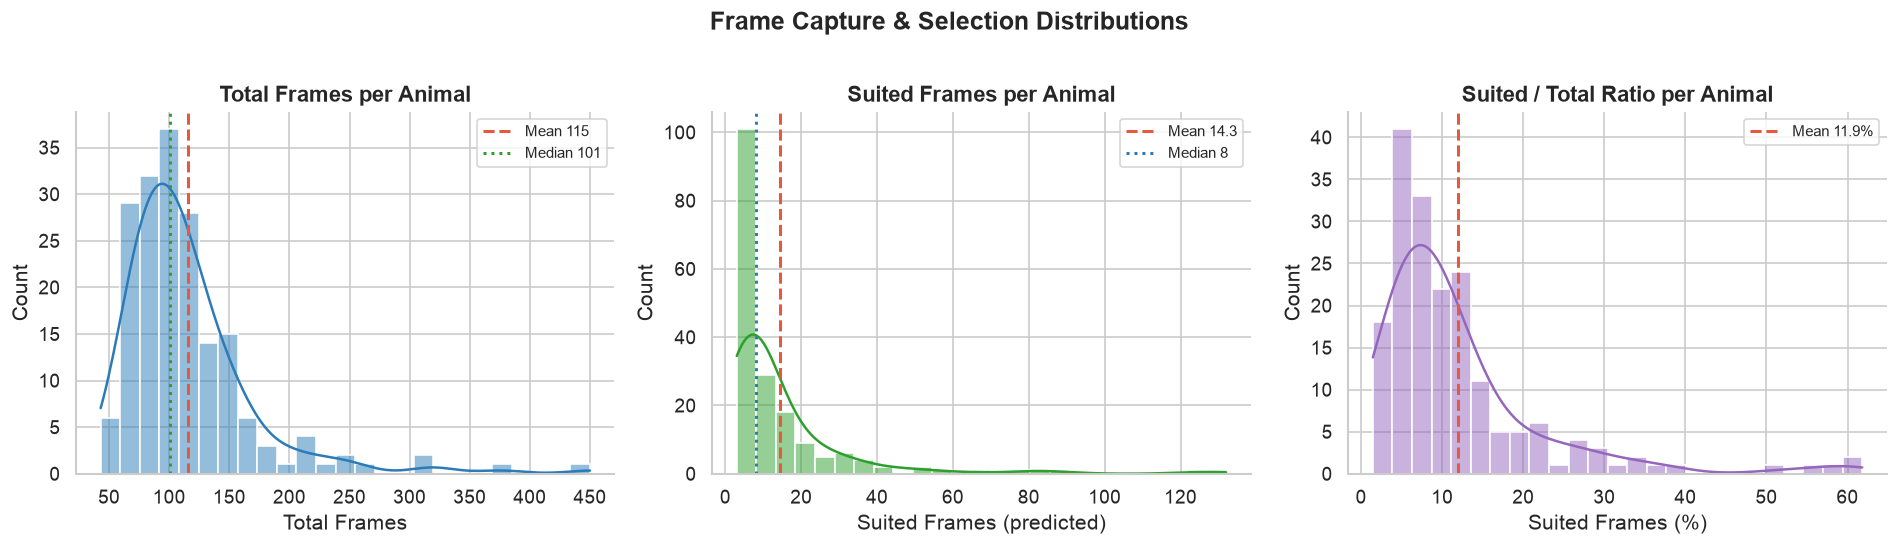


Total Frames  — mean: 115.3 | median: 101 | std: 55.0
Suited Frames — mean: 14.3 | median: 8 | std: 18.4
Suited %      — mean: 11.9% | median: 8.6%


In [8]:
df_rpt_clean = df_report[~df_report.is_outlier].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── (A) Distribution of total frames ────────────────────────────────────────
ax = axes[0]
sns.histplot(df_rpt_clean["total_frames"], bins=25, kde=True, color=ACCENT, ax=ax)
ax.axvline(df_rpt_clean["total_frames"].mean(),  color=WARN,     ls="--", lw=1.8, label=f"Mean {df_rpt_clean['total_frames'].mean():.0f}")
ax.axvline(df_rpt_clean["total_frames"].median(), color=OK_GREEN, ls=":",  lw=1.8, label=f"Median {df_rpt_clean['total_frames'].median():.0f}")
ax.set_title("Total Frames per Animal")
ax.set_xlabel("Total Frames")
ax.legend(fontsize=9)

# ── (B) Distribution of suited frames ───────────────────────────────────────
ax = axes[1]
sns.histplot(df_rpt_clean["suited_pred"], bins=25, kde=True, color=OK_GREEN, ax=ax)
ax.axvline(df_rpt_clean["suited_pred"].mean(),  color=WARN, ls="--", lw=1.8, label=f"Mean {df_rpt_clean['suited_pred'].mean():.1f}")
ax.axvline(df_rpt_clean["suited_pred"].median(), color=ACCENT, ls=":", lw=1.8, label=f"Median {df_rpt_clean['suited_pred'].median():.0f}")
ax.set_title("Suited Frames per Animal")
ax.set_xlabel("Suited Frames (predicted)")
ax.legend(fontsize=9)

# ── (C) Suited / Total ratio distribution ───────────────────────────────────
ax = axes[2]
suited_pct = df_rpt_clean["suited_pred"] / df_rpt_clean["total_frames"] * 100
sns.histplot(suited_pct, bins=25, kde=True, color=PALETTE[3], ax=ax)
ax.axvline(suited_pct.mean(), color=WARN, ls="--", lw=1.8, label=f"Mean {suited_pct.mean():.1f}%")
ax.set_title("Suited / Total Ratio per Animal")
ax.set_xlabel("Suited Frames (%)")
ax.legend(fontsize=9)

plt.suptitle("Frame Capture & Selection Distributions", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_frame_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nTotal Frames  — mean: {df_rpt_clean['total_frames'].mean():.1f} | median: {df_rpt_clean['total_frames'].median():.0f} | std: {df_rpt_clean['total_frames'].std():.1f}")
print(f"Suited Frames — mean: {df_rpt_clean['suited_pred'].mean():.1f} | median: {df_rpt_clean['suited_pred'].median():.0f} | std: {df_rpt_clean['suited_pred'].std():.1f}")
print(f"Suited %      — mean: {suited_pct.mean():.1f}% | median: {suited_pct.median():.1f}%")


## 3. Prediction Error Analysis

Distribution of absolute and relative errors across all animals, with and without statistical outliers.


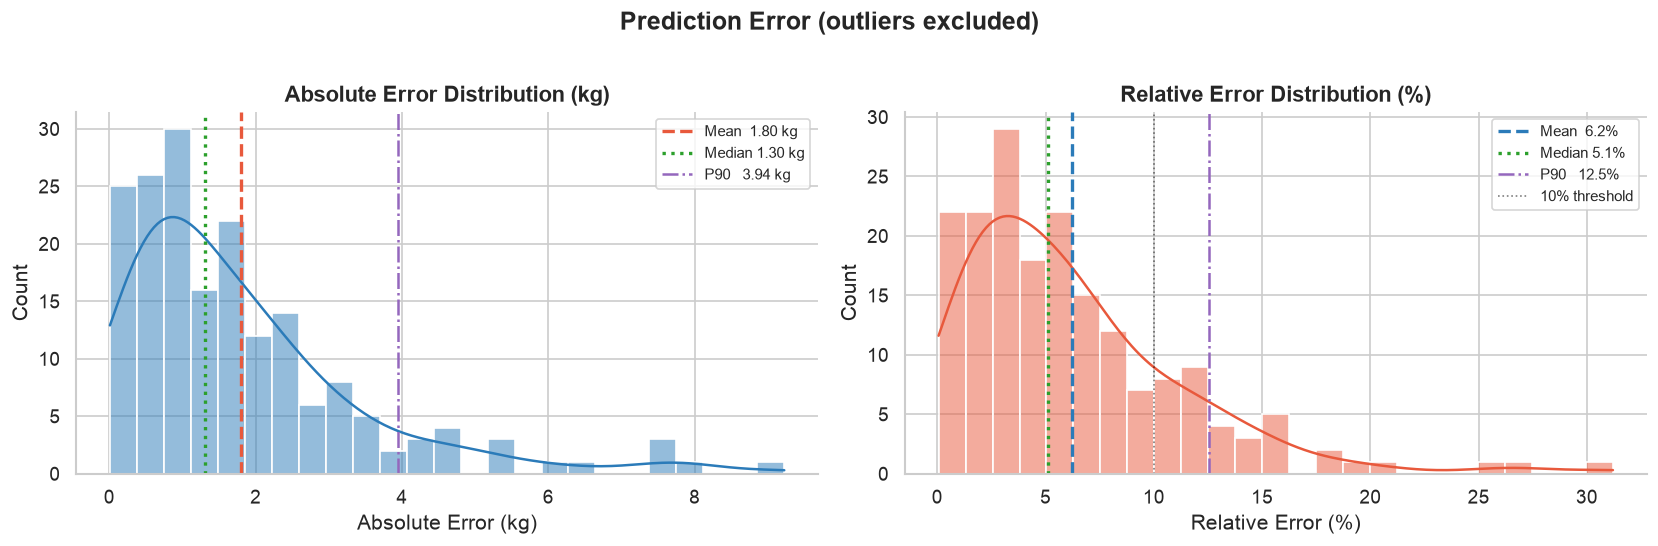

Animals with relative error < 10% : 147/183 (80.3%)
Animals with relative error > 20% : 4
P25/P50/P75/P90 of relative error : 2.7% / 5.1% / 8.3% / 12.5%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ── Absolute Error ──────────────────────────────────────────────────────────
ax = axes[0]
data_ae = df_rpt_clean["abs_error"]
sns.histplot(data_ae, bins=25, kde=True, color=ACCENT, ax=ax)
ax.axvline(data_ae.mean(),   color=WARN,     ls="--", lw=2, label=f"Mean  {data_ae.mean():.2f} kg")
ax.axvline(data_ae.median(), color=OK_GREEN, ls=":",  lw=2, label=f"Median {data_ae.median():.2f} kg")
ax.axvline(np.percentile(data_ae, 90), color=PALETTE[3], ls="-.", lw=1.5, label=f"P90   {np.percentile(data_ae, 90):.2f} kg")
ax.set_title("Absolute Error Distribution (kg)")
ax.set_xlabel("Absolute Error (kg)")
ax.legend(fontsize=9)

# ── Relative Error ──────────────────────────────────────────────────────────
ax = axes[1]
data_re = df_rpt_clean["rel_error_pct"]
sns.histplot(data_re, bins=25, kde=True, color=WARN, ax=ax)
ax.axvline(data_re.mean(),   color=ACCENT,  ls="--", lw=2, label=f"Mean  {data_re.mean():.1f}%")
ax.axvline(data_re.median(), color=OK_GREEN, ls=":", lw=2, label=f"Median {data_re.median():.1f}%")
ax.axvline(np.percentile(data_re, 90), color=PALETTE[3], ls="-.", lw=1.5, label=f"P90   {np.percentile(data_re, 90):.1f}%")
ax.axvline(10, color="black", ls=":", lw=1, alpha=0.5, label="10% threshold")
ax.set_title("Relative Error Distribution (%)")
ax.set_xlabel("Relative Error (%)")
ax.legend(fontsize=9)

plt.suptitle("Prediction Error (outliers excluded)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_error_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

below_10 = (data_re < 10).sum()
print(f"Animals with relative error < 10% : {below_10}/{len(data_re)} ({below_10/len(data_re)*100:.1f}%)")
print(f"Animals with relative error > 20% : {(data_re > 20).sum()}")
print(f"P25/P50/P75/P90 of relative error : "
      f"{np.percentile(data_re,25):.1f}% / {data_re.median():.1f}% / "
      f"{np.percentile(data_re,75):.1f}% / {np.percentile(data_re,90):.1f}%")


## 4. Core Tradeoff: Suited Frames → Prediction Error

The central hypothesis is: **more suited frames should average out noise and reduce prediction error**.
We examine this relationship directly.


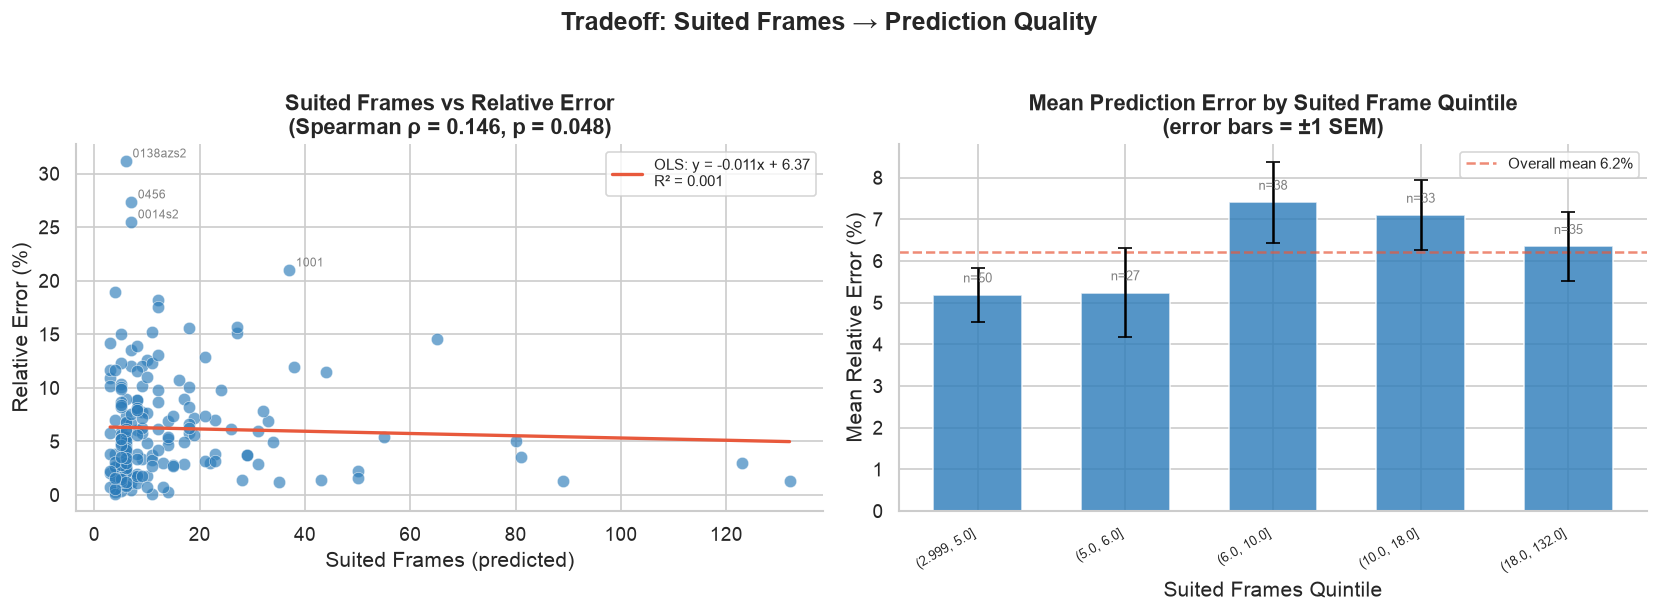

Spearman ρ (suited frames vs rel error) = 0.146  (p=0.0479)

Binned summary:
   suited_bin  mean_rel_error  sem_rel_error  count
 (2.999, 5.0]        5.185400       0.640602     50
   (5.0, 6.0]        5.236296       1.070026     27
  (6.0, 10.0]        7.408421       0.977279     38
 (10.0, 18.0]        7.098485       0.842998     33
(18.0, 132.0]        6.348857       0.830035     35


In [10]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (A) Scatter: suited_pred vs rel_error_pct ───────────────────────────────
ax = axes[0]
x = df_rpt_clean["suited_pred"]
y = df_rpt_clean["rel_error_pct"]
ax.scatter(x, y, alpha=0.65, s=55, color=ACCENT, edgecolors="white", lw=0.4)

# Trend line
m, b, r, p, _ = stats.linregress(x, y)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m*xline + b, color=WARN, lw=2,
        label=f"OLS: y = {m:.3f}x + {b:.2f}\nR² = {r**2:.3f}")

rho, pval = spearmanr(x, y)
ax.set_title(f"Suited Frames vs Relative Error\n(Spearman ρ = {rho:.3f}, p = {pval:.3f})")
ax.set_xlabel("Suited Frames (predicted)")
ax.set_ylabel("Relative Error (%)")
ax.legend(fontsize=9)

# Annotate high-error outliers
for _, row in df_rpt_clean[df_rpt_clean.rel_error_pct > 20].iterrows():
    ax.annotate(row.animal_id, (row.suited_pred, row.rel_error_pct),
                fontsize=7, xytext=(4, 2), textcoords="offset points", color="grey")

# ── (B) Binned view: mean error by suited-frame quintiles ───────────────────
ax = axes[1]
df_rpt_clean = df_rpt_clean.copy()
df_rpt_clean["suited_bin"] = pd.qcut(df_rpt_clean["suited_pred"], q=5, duplicates="drop")
binned = df_rpt_clean.groupby("suited_bin", observed=True).agg(
    mean_rel_error=("rel_error_pct", "mean"),
    sem_rel_error= ("rel_error_pct", lambda s: s.sem()),
    count=         ("rel_error_pct", "size"),
).reset_index()

bars = ax.bar(range(len(binned)), binned["mean_rel_error"], color=ACCENT,
              alpha=0.8, width=0.6, zorder=2)
ax.errorbar(range(len(binned)), binned["mean_rel_error"],
            yerr=binned["sem_rel_error"], fmt="none", color="black",
            capsize=4, linewidth=1.5, zorder=3)
for i, (_, row) in enumerate(binned.iterrows()):
    ax.text(i, row.mean_rel_error + 0.3, f"n={row['count']}", ha="center", fontsize=8, color="grey")

ax.set_xticks(range(len(binned)))
ax.set_xticklabels([str(b) for b in binned["suited_bin"]], rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Suited Frames Quintile")
ax.set_ylabel("Mean Relative Error (%)")
ax.set_title("Mean Prediction Error by Suited Frame Quintile\n(error bars = ±1 SEM)")
ax.axhline(df_rpt_clean["rel_error_pct"].mean(), color=WARN, ls="--", lw=1.5, alpha=0.7,
           label=f"Overall mean {df_rpt_clean['rel_error_pct'].mean():.1f}%")
ax.legend(fontsize=9)

plt.suptitle("Tradeoff: Suited Frames → Prediction Quality", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_suited_vs_error.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Spearman ρ (suited frames vs rel error) = {rho:.3f}  (p={pval:.4f})")
print("\nBinned summary:")
print(binned.to_string(index=False))


## 5. More Frames ≠ More Suited Frames

High FPS → more raw frames, but does it yield more suited frames? We check how the selector converts total frames into usable ones.


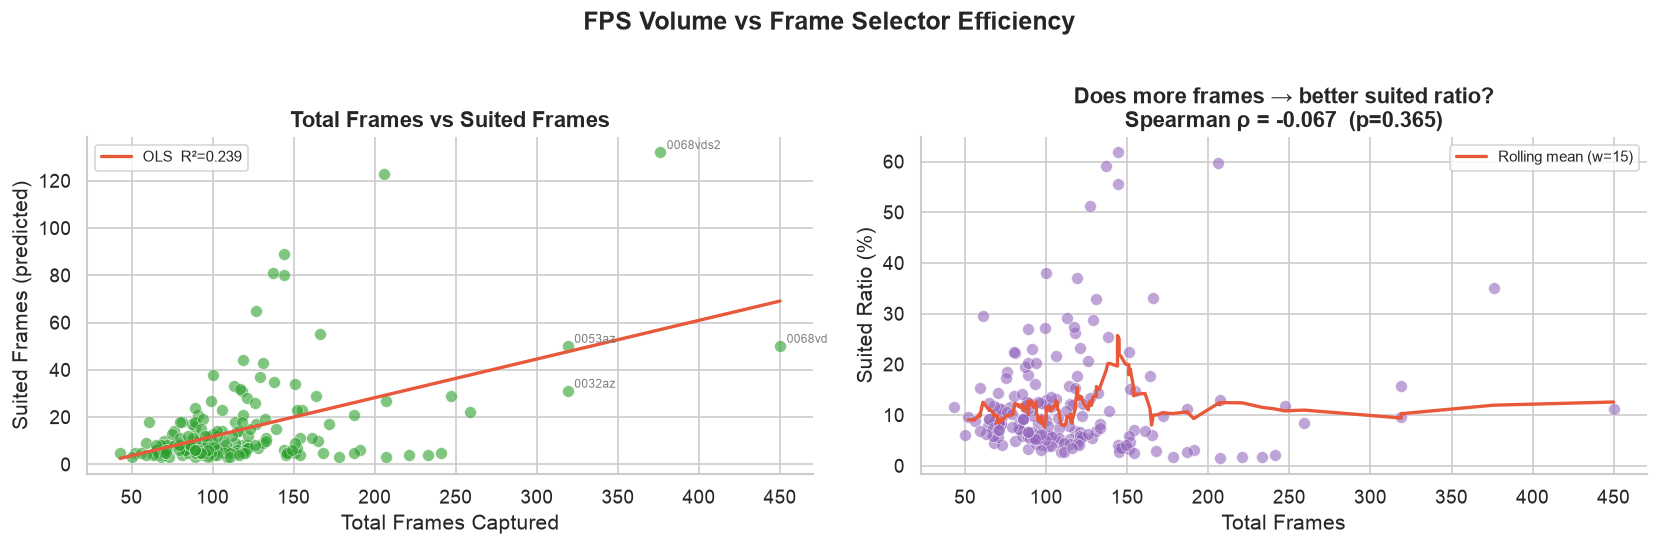

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ── (A) Total vs suited scatter ──────────────────────────────────────────────
ax = axes[0]
x = df_rpt_clean["total_frames"]
y = df_rpt_clean["suited_pred"]
ax.scatter(x, y, alpha=0.6, s=50, color=OK_GREEN, edgecolors="white", lw=0.4)
m, b, r, p, _ = stats.linregress(x, y)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m*xline + b, color=WARN, lw=2, label=f"OLS  R²={r**2:.3f}")
ax.set_xlabel("Total Frames Captured")
ax.set_ylabel("Suited Frames (predicted)")
ax.set_title("Total Frames vs Suited Frames")
ax.legend(fontsize=9)

for _, row in df_rpt_clean.nlargest(4, "total_frames").iterrows():
    ax.annotate(row.animal_id, (row.total_frames, row.suited_pred),
                fontsize=7, xytext=(4, 2), textcoords="offset points", color="grey")

# ── (B) Suited ratio vs total frames ────────────────────────────────────────
ax = axes[1]
suited_pct2 = df_rpt_clean["suited_pred"] / df_rpt_clean["total_frames"] * 100
ax.scatter(df_rpt_clean["total_frames"], suited_pct2, alpha=0.6, s=50,
           color=PALETTE[3], edgecolors="white", lw=0.4)
rho2, pval2 = spearmanr(df_rpt_clean["total_frames"], suited_pct2)
ax.set_xlabel("Total Frames")
ax.set_ylabel("Suited Ratio (%)")
ax.set_title(f"Does more frames → better suited ratio?\nSpearman ρ = {rho2:.3f}  (p={pval2:.3f})")
# LOWESS-style moving average
df_s = df_rpt_clean.assign(suited_pct=suited_pct2).sort_values("total_frames")
roll = df_s.rolling(15, on="total_frames", min_periods=3)["suited_pct"].mean()
ax.plot(df_s["total_frames"], roll, color=WARN, lw=2, label="Rolling mean (w=15)")
ax.legend(fontsize=9)

plt.suptitle("FPS Volume vs Frame Selector Efficiency", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_total_vs_suited.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Selector Quality: Precision, Recall & F1

How well does the suitability classifier separate good frames from bad ones?
We also ask whether low F1-score correlates with higher prediction error.


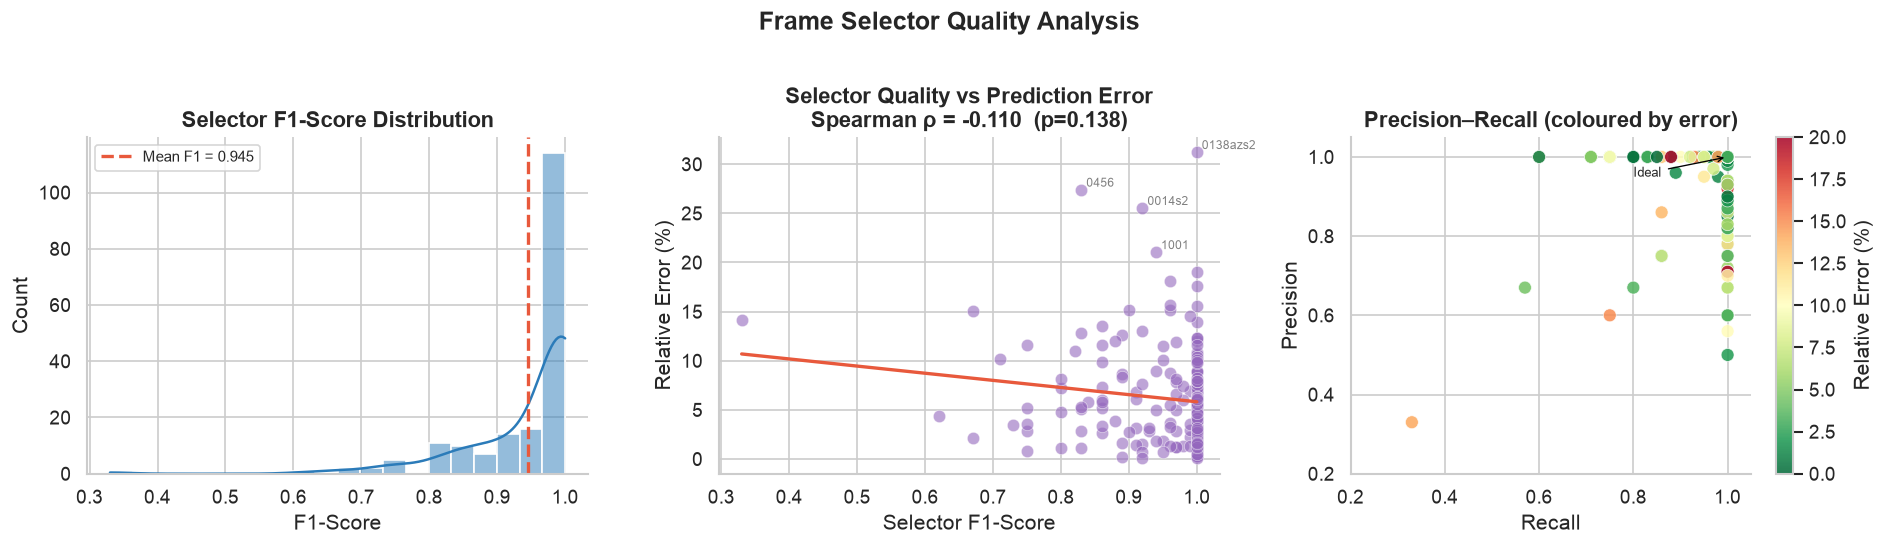

Animals with perfect F1 (1.0) : 53.0%
Animals with F1 < 0.80        : 11


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── (A) F1-score distribution ────────────────────────────────────────────────
ax = axes[0]
sns.histplot(df_rpt_clean["f1"], bins=20, kde=True, color=ACCENT, ax=ax)
ax.axvline(df_rpt_clean["f1"].mean(), color=WARN, ls="--", lw=2,
           label=f"Mean F1 = {df_rpt_clean['f1'].mean():.3f}")
ax.set_xlabel("F1-Score")
ax.set_title("Selector F1-Score Distribution")
ax.legend(fontsize=9)

# ── (B) F1 vs Relative Error ─────────────────────────────────────────────────
ax = axes[1]
ax.scatter(df_rpt_clean["f1"], df_rpt_clean["rel_error_pct"],
           alpha=0.6, s=55, color=PALETTE[3], edgecolors="white", lw=0.4)
rho3, pval3 = spearmanr(df_rpt_clean["f1"], df_rpt_clean["rel_error_pct"])
m, b, r, p, _ = stats.linregress(df_rpt_clean["f1"], df_rpt_clean["rel_error_pct"])
xline = np.linspace(df_rpt_clean["f1"].min(), 1, 100)
ax.plot(xline, m*xline + b, color=WARN, lw=2)
ax.set_xlabel("Selector F1-Score")
ax.set_ylabel("Relative Error (%)")
ax.set_title(f"Selector Quality vs Prediction Error\nSpearman ρ = {rho3:.3f}  (p={pval3:.3f})")

for _, row in df_rpt_clean[df_rpt_clean.rel_error_pct > 20].iterrows():
    ax.annotate(row.animal_id, (row.f1, row.rel_error_pct),
                fontsize=7, xytext=(3, 2), textcoords="offset points", color="grey")

# ── (C) Precision-Recall scatter ─────────────────────────────────────────────
ax = axes[2]
sc = ax.scatter(df_rpt_clean["recall"], df_rpt_clean["precision"],
                c=df_rpt_clean["rel_error_pct"], cmap="RdYlGn_r",
                vmin=0, vmax=20, s=60, edgecolors="white", lw=0.4, alpha=0.85)
plt.colorbar(sc, ax=ax, label="Relative Error (%)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall (coloured by error)")
ax.set_xlim(0.2, 1.05); ax.set_ylim(0.2, 1.05)
# ideal corner annotation
ax.annotate("Ideal", xy=(1, 1), xytext=(0.80, 0.95),
            arrowprops=dict(arrowstyle="->", color="black", lw=0.8), fontsize=8)

plt.suptitle("Frame Selector Quality Analysis", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_selector_quality.png", dpi=120, bbox_inches="tight")
plt.show()

pct_f1_perfect = (df_rpt_clean["f1"] == 1.0).mean()*100
print(f"Animals with perfect F1 (1.0) : {pct_f1_perfect:.1f}%")
print(f"Animals with F1 < 0.80        : {(df_rpt_clean.f1 < 0.80).sum()}")


## 7. Per-Animal Timing: Lead Time, Latency & Processing Delay

- **Lead time**: first capture → final prediction
- **Latency**: last capture → final prediction (model's reaction time)
- **Processing delay**: cumulative inference time for suited frames


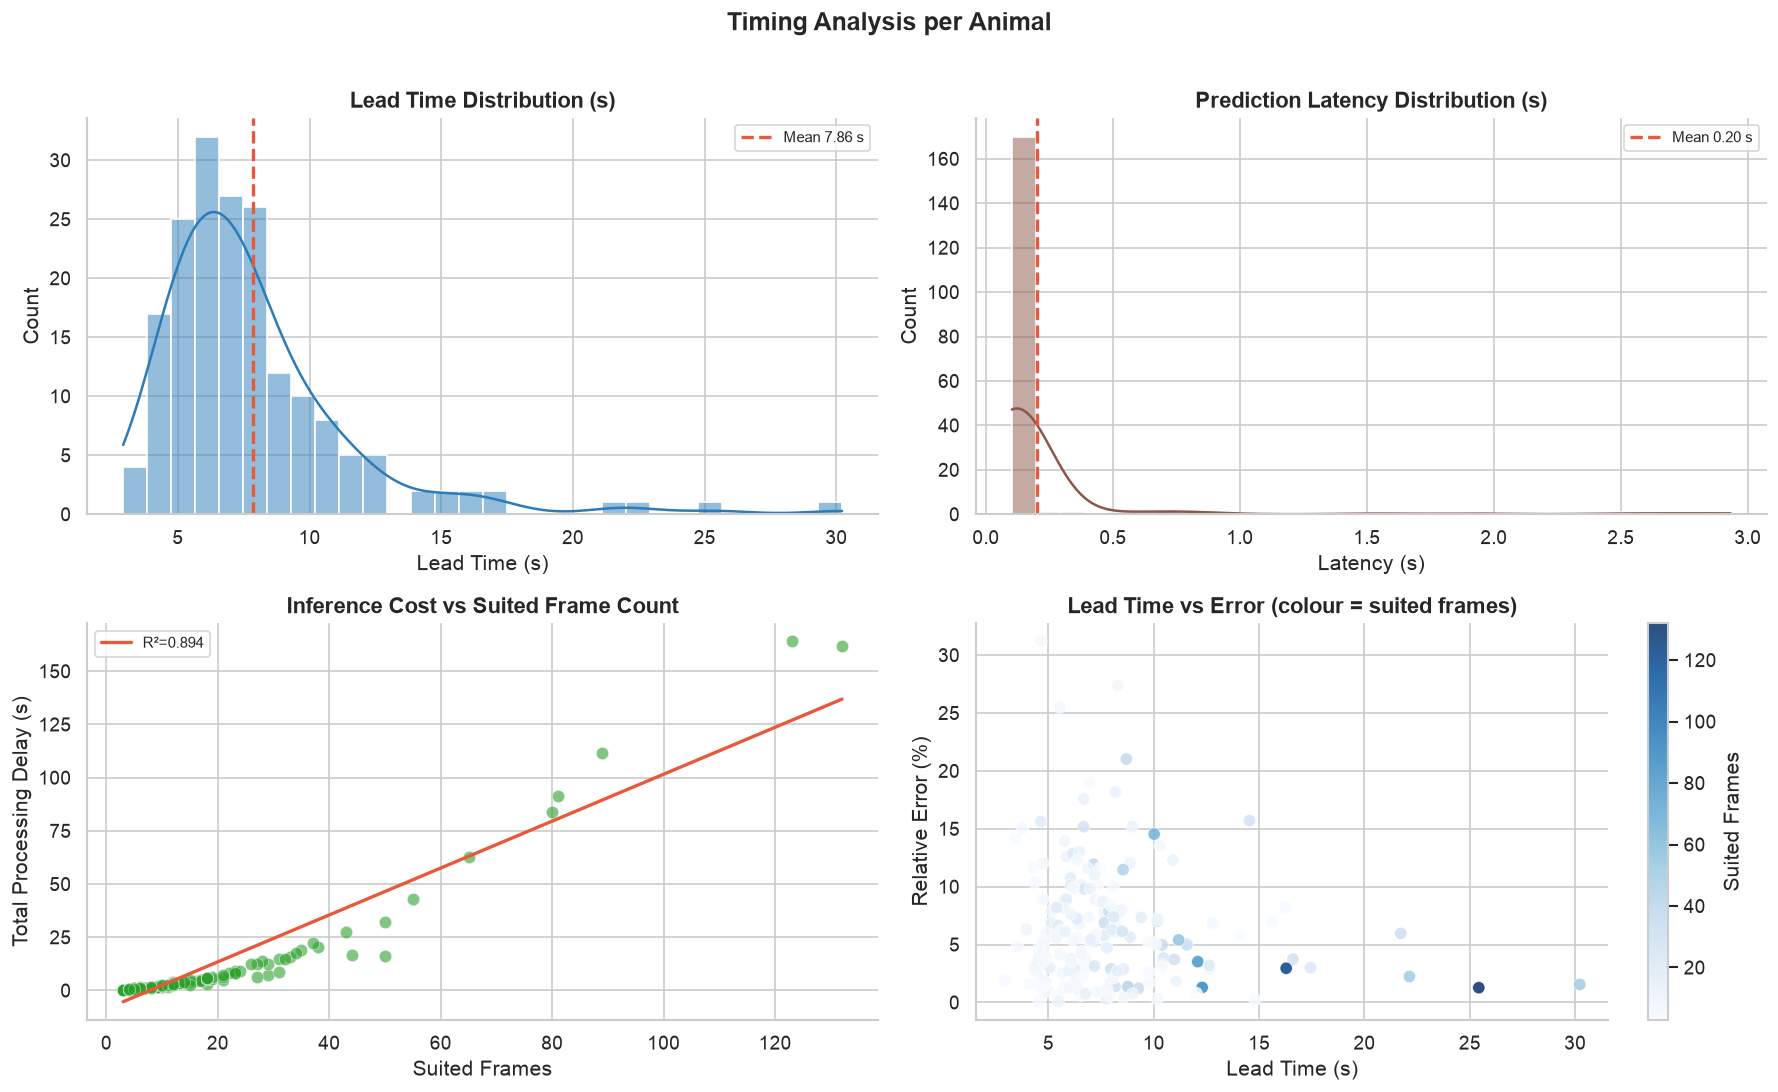

Lead time  — mean: 7.862 s | median: 6.868 s | max: 30.214 s
Latency    — mean: 0.202 s | median: 0.123 s


In [13]:
# Merge metrics.json timing with report data
df_timing = df_animals.merge(
    df_report[["animal_id","suited_pred","rel_error_pct","f1","is_outlier"]],
    on="animal_id", how="inner"
)
df_timing_clean = df_timing[~df_timing.is_outlier].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ── (A) Lead time distribution ───────────────────────────────────────────────
ax = axes[0][0]
lt = df_timing_clean["by_animal_lead_time_sec"].dropna()
sns.histplot(lt, bins=30, kde=True, color=ACCENT, ax=ax)
ax.axvline(lt.mean(), color=WARN, ls="--", lw=2, label=f"Mean {lt.mean():.2f} s")
ax.set_title("Lead Time Distribution (s)")
ax.set_xlabel("Lead Time (s)")
ax.legend(fontsize=9)

# ── (B) Latency distribution ─────────────────────────────────────────────────
ax = axes[0][1]
lat = df_timing_clean["by_animal_latency_sec"].dropna()
sns.histplot(lat, bins=30, kde=True, color=PALETTE[4], ax=ax)
ax.axvline(lat.mean(), color=WARN, ls="--", lw=2, label=f"Mean {lat.mean():.2f} s")
ax.set_title("Prediction Latency Distribution (s)")
ax.set_xlabel("Latency (s)")
ax.legend(fontsize=9)

# ── (C) Processing delay vs suited frames ────────────────────────────────────
ax = axes[1][0]
ax.scatter(df_timing_clean["suited_pred"],
           df_timing_clean["by_animal_processing_delay_sec"],
           alpha=0.6, s=55, color=OK_GREEN, edgecolors="white", lw=0.4)
x  = df_timing_clean["suited_pred"].dropna()
y2 = df_timing_clean["by_animal_processing_delay_sec"].dropna()
common_idx = x.index.intersection(y2.index)
m, b, r, p, _ = stats.linregress(x.loc[common_idx], y2.loc[common_idx])
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m*xline+b, color=WARN, lw=2, label=f"R²={r**2:.3f}")
ax.set_xlabel("Suited Frames")
ax.set_ylabel("Total Processing Delay (s)")
ax.set_title("Inference Cost vs Suited Frame Count")
ax.legend(fontsize=9)

# ── (D) Lead time vs relative error ──────────────────────────────────────────
ax = axes[1][1]
sc2 = ax.scatter(df_timing_clean["by_animal_lead_time_sec"],
                 df_timing_clean["rel_error_pct"],
                 c=df_timing_clean["suited_pred"],
                 cmap="Blues", s=55, edgecolors="white", lw=0.4, alpha=0.85)
plt.colorbar(sc2, ax=ax, label="Suited Frames")
ax.set_xlabel("Lead Time (s)")
ax.set_ylabel("Relative Error (%)")
ax.set_title("Lead Time vs Error (colour = suited frames)")

plt.suptitle("Timing Analysis per Animal", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_timing_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Lead time  — mean: {lt.mean():.3f} s | median: {lt.median():.3f} s | max: {lt.max():.3f} s")
print(f"Latency    — mean: {lat.mean():.3f} s | median: {lat.median():.3f} s")


## 8. Edge Resource Telemetry — CPU, RAM & Temperature

Resource consumption characterised over the full run, with per-core breakdown and distribution analysis.


In [14]:
cpu_avg  = df_cpu["cpu_mean"].mean()
ram_avg  = df_mem["percent"].mean()
temp_avg = df_temp["temperature"].mean()

print(f"CPU  mean: {cpu_avg:.2f}%   peak: {df_cpu['cpu_mean'].max():.1f}%")
print(f"RAM  mean: {ram_avg:.2f}%   used GB (mean): {df_mem['ram_gb'].mean():.2f}")
print(f"TEMP mean: {temp_avg:.2f}°C  peak: {df_temp['temperature'].max():.1f}°C")


CPU  mean: 20.85%   peak: 75.3%
RAM  mean: 5.55%   used GB (mean): 0.94
TEMP mean: 60.33°C  peak: 74.3°C


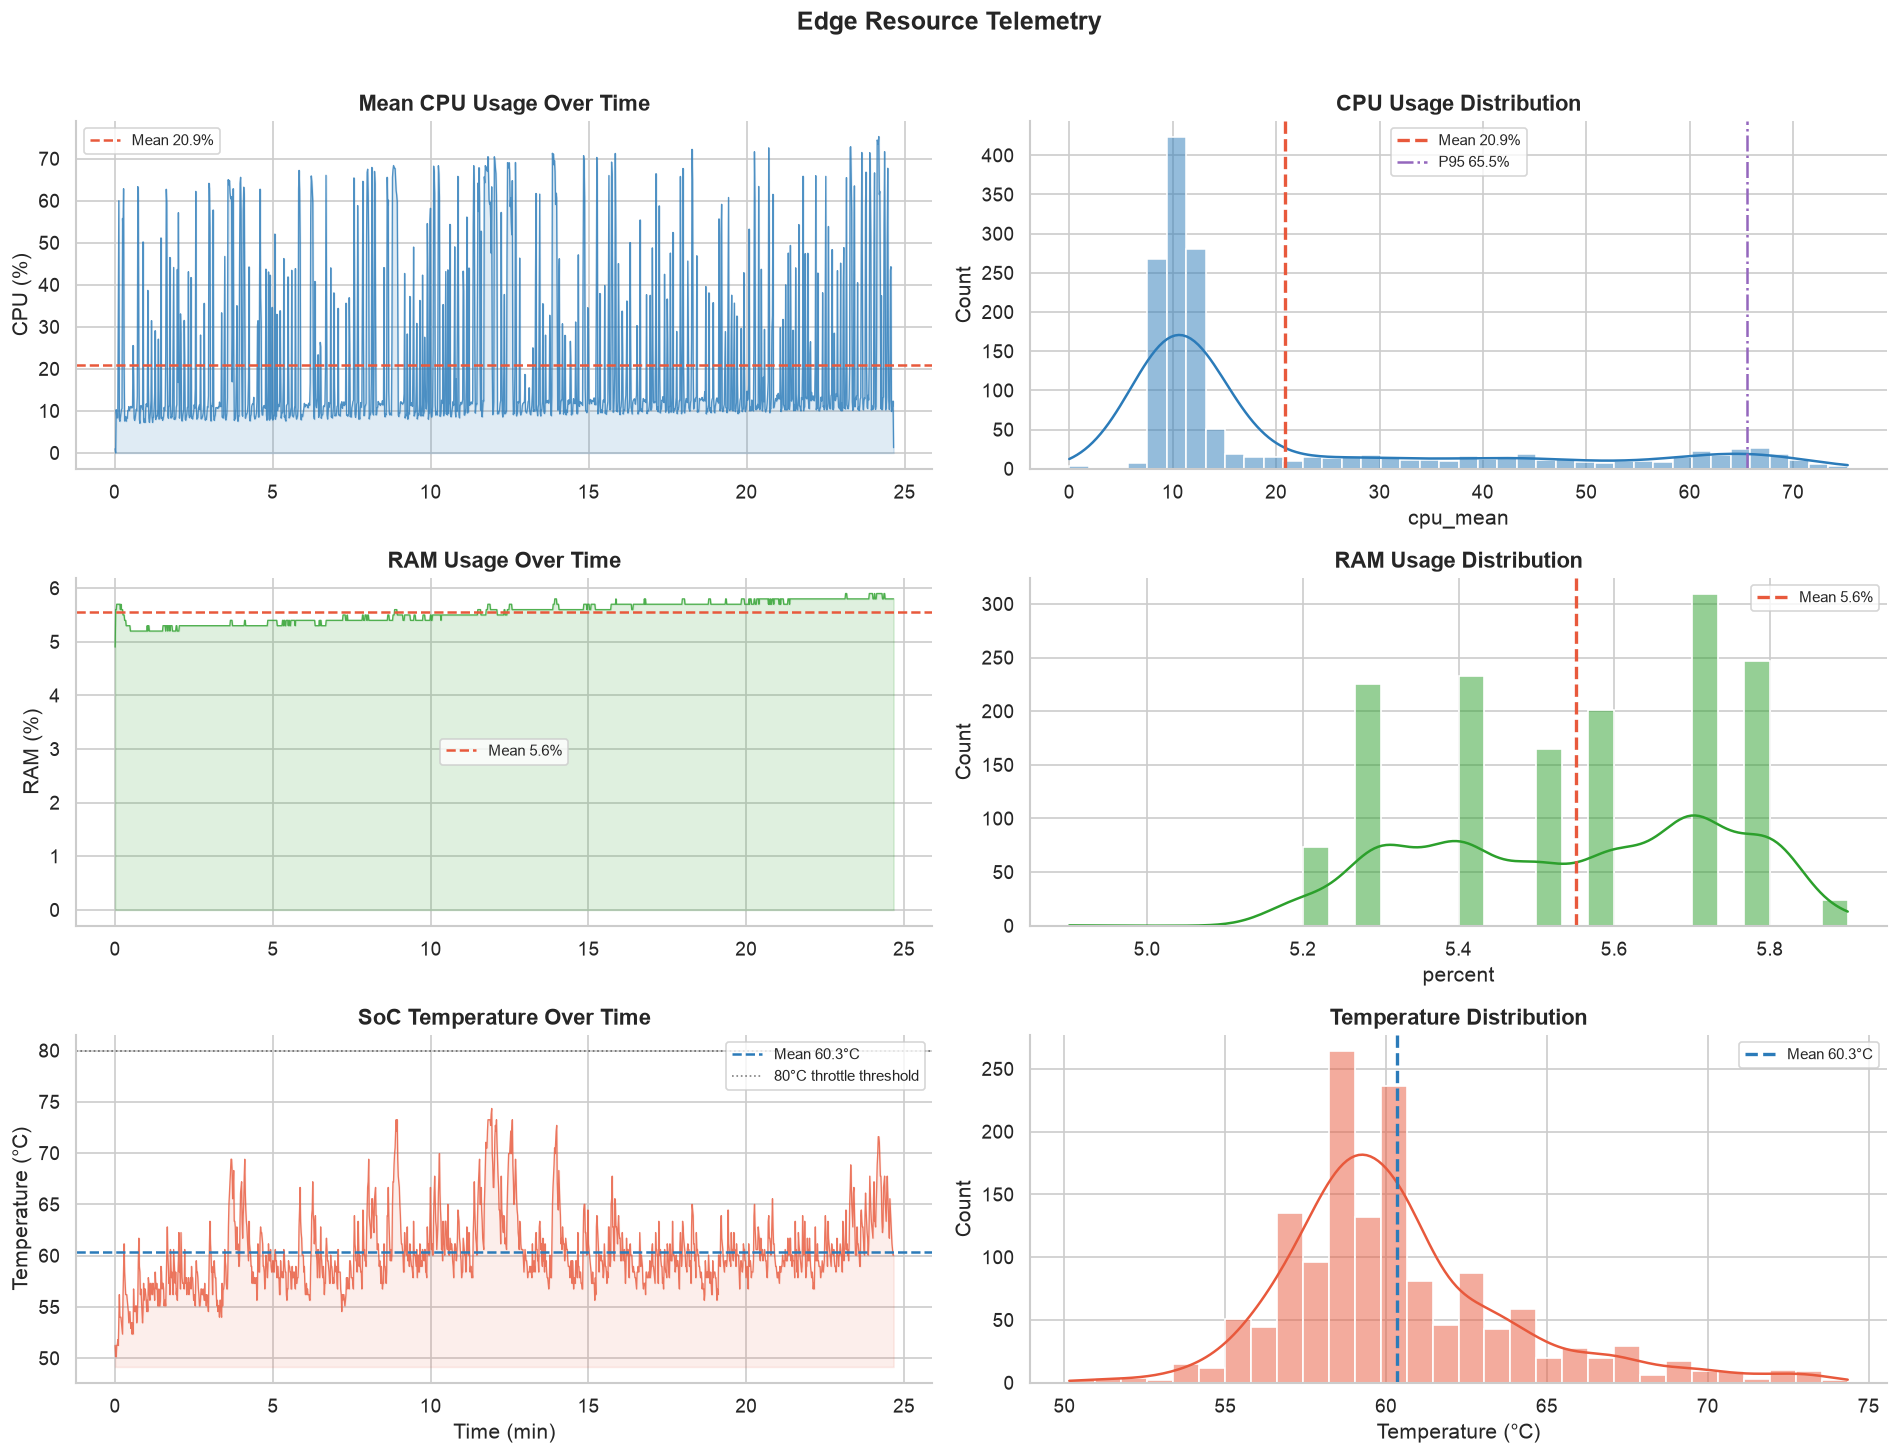

In [15]:
min_ts = min(df_cpu["timestamp"].min(), df_mem["timestamp"].min(), df_temp["timestamp"].min())
df_cpu["t_min"]  = (df_cpu["timestamp"]  - min_ts).dt.total_seconds() / 60
df_mem["t_min"]  = (df_mem["timestamp"]  - min_ts).dt.total_seconds() / 60
df_temp["t_min"] = (df_temp["timestamp"] - min_ts).dt.total_seconds() / 60

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# ── CPU over time & distribution ─────────────────────────────────────────────
ax = axes[0][0]
ax.plot(df_cpu["t_min"], df_cpu["cpu_mean"], color=ACCENT, lw=0.8, alpha=0.8)
ax.fill_between(df_cpu["t_min"], df_cpu["cpu_mean"], alpha=0.15, color=ACCENT)
ax.axhline(cpu_avg, color=WARN, ls="--", lw=1.5, label=f"Mean {cpu_avg:.1f}%")
ax.set_title("Mean CPU Usage Over Time")
ax.set_ylabel("CPU (%)")
ax.legend(fontsize=9)

ax = axes[0][1]
sns.histplot(df_cpu["cpu_mean"], bins=40, kde=True, color=ACCENT, ax=ax)
ax.axvline(cpu_avg, color=WARN, ls="--", lw=2, label=f"Mean {cpu_avg:.1f}%")
ax.axvline(df_cpu["cpu_mean"].quantile(0.95), color=PALETTE[3], ls="-.", lw=1.5,
           label=f"P95 {df_cpu['cpu_mean'].quantile(0.95):.1f}%")
ax.set_title("CPU Usage Distribution")
ax.legend(fontsize=9)

# ── RAM over time & distribution ─────────────────────────────────────────────
ax = axes[1][0]
ax.plot(df_mem["t_min"], df_mem["percent"], color=OK_GREEN, lw=0.8, alpha=0.8)
ax.fill_between(df_mem["t_min"], df_mem["percent"], alpha=0.15, color=OK_GREEN)
ax.axhline(ram_avg, color=WARN, ls="--", lw=1.5, label=f"Mean {ram_avg:.1f}%")
ax.set_title("RAM Usage Over Time")
ax.set_ylabel("RAM (%)")
ax.legend(fontsize=9)

ax = axes[1][1]
sns.histplot(df_mem["percent"], bins=30, kde=True, color=OK_GREEN, ax=ax)
ax.axvline(ram_avg, color=WARN, ls="--", lw=2, label=f"Mean {ram_avg:.1f}%")
ax.set_title("RAM Usage Distribution")
ax.legend(fontsize=9)

# ── Temperature over time & distribution ─────────────────────────────────────
ax = axes[2][0]
ax.plot(df_temp["t_min"], df_temp["temperature"], color=WARN, lw=0.8, alpha=0.8)
ax.fill_between(df_temp["t_min"], df_temp["temperature"],
                df_temp["temperature"].min()-1, alpha=0.1, color=WARN)
ax.axhline(temp_avg, color=ACCENT, ls="--", lw=1.5, label=f"Mean {temp_avg:.1f}°C")
ax.axhline(80, color="black", ls=":", lw=1, alpha=0.5, label="80°C throttle threshold")
ax.set_title("SoC Temperature Over Time")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Time (min)")
ax.legend(fontsize=9)

ax = axes[2][1]
sns.histplot(df_temp["temperature"], bins=30, kde=True, color=WARN, ax=ax)
ax.axvline(temp_avg, color=ACCENT, ls="--", lw=2, label=f"Mean {temp_avg:.1f}°C")
ax.set_title("Temperature Distribution")
ax.set_xlabel("Temperature (°C)")
ax.legend(fontsize=9)

plt.suptitle("Edge Resource Telemetry", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_resource_telemetry.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Timeline: Animal Processing vs Resource Consumption

Aligning the animal processing Gantt chart with CPU and temperature on the same time axis reveals **idle periods** where the system waits for the next animal, and **burst periods** where resources spike.


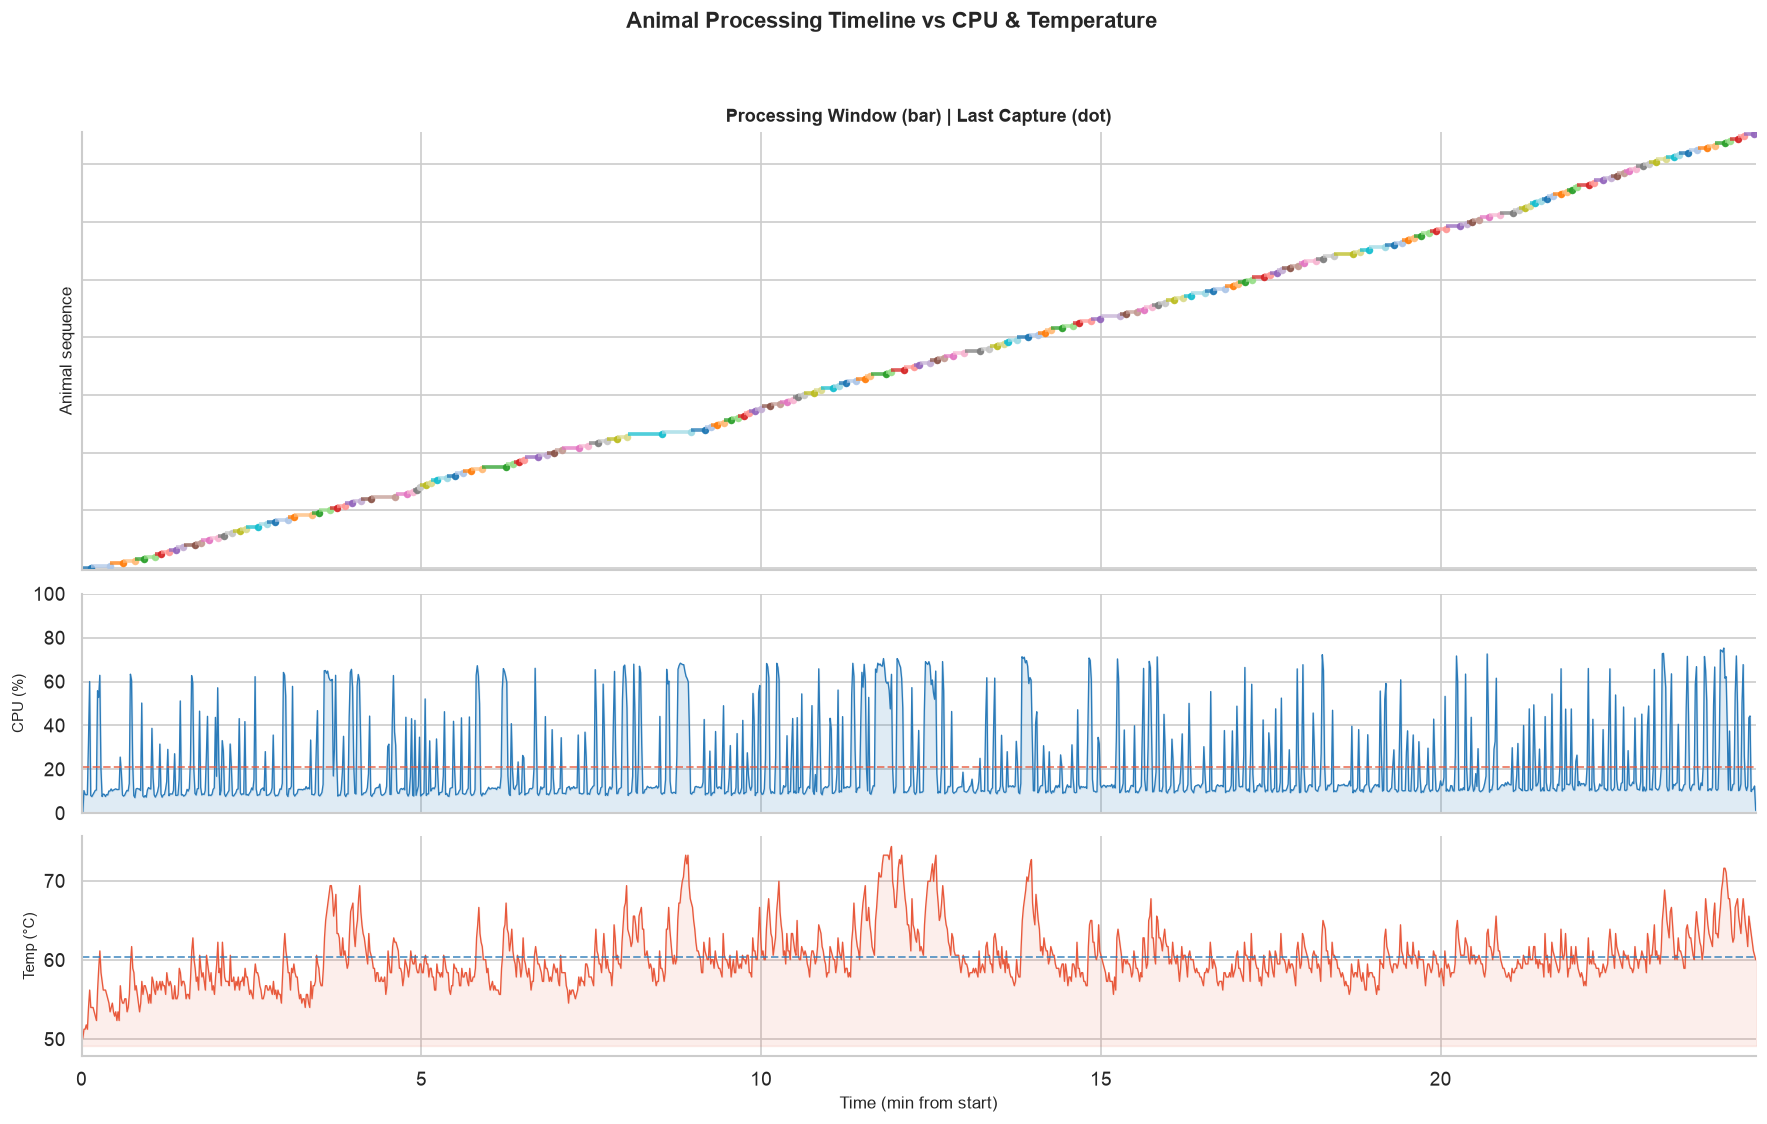

In [16]:
df_animals_sorted = df_animals.sort_values("first_image_capture_time").reset_index(drop=True)
global_min_ts = min(
    df_animals_sorted["first_image_capture_time"].min(),
    df_cpu["timestamp"].min()
)

def to_min(ts):
    return (ts - global_min_ts).total_seconds() / 60

df_animals_sorted["t_start_min"] = df_animals_sorted["first_image_capture_time"].apply(to_min)
df_animals_sorted["t_end_min"]   = df_animals_sorted["weight_prediction_final"].apply(
    lambda x: to_min(x) if pd.notna(x) else np.nan)
df_animals_sorted["t_lastcap_min"] = df_animals_sorted["last_image_capture_time"].apply(to_min)

df_cpu["t2_min"]  = df_cpu["timestamp"].apply(to_min)
df_temp["t2_min"] = df_temp["timestamp"].apply(to_min)

max_t = max(df_animals_sorted["t_end_min"].max(), df_cpu["t2_min"].max())

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.08)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax2 = fig.add_subplot(gs[2], sharex=ax0)

N = len(df_animals_sorted)
COLORS = plt.cm.tab20(np.linspace(0, 1, 20))

for i, row in df_animals_sorted.iterrows():
    if pd.isna(row["t_end_min"]):
        continue
    col = COLORS[i % 20]
    ax0.hlines(i, row["t_start_min"], row["t_end_min"],
               color=col, lw=2.2, alpha=0.75)
    ax0.plot(row["t_lastcap_min"], i, "o", color=col, ms=3.5, alpha=0.9)

ax0.set_xlim(0, max_t)
ax0.set_ylabel("Animal sequence", fontsize=10)
ax0.set_title("Processing Window (bar) | Last Capture (dot)", fontsize=11, fontweight="bold")
ax0.yaxis.set_tick_params(labelleft=False)
ax0.set_ylim(-1, N)

ax1.plot(df_cpu["t2_min"], df_cpu["cpu_mean"], color=ACCENT, lw=0.8)
ax1.fill_between(df_cpu["t2_min"], df_cpu["cpu_mean"], alpha=0.15, color=ACCENT)
ax1.axhline(cpu_avg, color=WARN, ls="--", lw=1.2, alpha=0.7)
ax1.set_ylabel("CPU (%)", fontsize=9)
ax1.set_ylim(0, 100)

ax2.plot(df_temp["t2_min"], df_temp["temperature"], color=WARN, lw=0.8)
ax2.fill_between(df_temp["t2_min"], df_temp["temperature"],
                 df_temp["temperature"].min()-1, alpha=0.1, color=WARN)
ax2.axhline(temp_avg, color=ACCENT, ls="--", lw=1.2, alpha=0.7)
ax2.set_ylabel("Temp (°C)", fontsize=9)
ax2.set_xlabel("Time (min from start)", fontsize=10)

plt.setp(ax0.get_xticklabels(), visible=False)
plt.setp(ax1.get_xticklabels(), visible=False)
fig.suptitle("Animal Processing Timeline vs CPU & Temperature", fontweight="bold", fontsize=13, y=0.98)
plt.savefig("fig_timeline_overlay.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Does Number of Suited Frames Drive Resource Usage?

We align per-animal suited frame counts with CPU/temperature samples collected *during* each animal's processing window to quantify the resource footprint per animal.


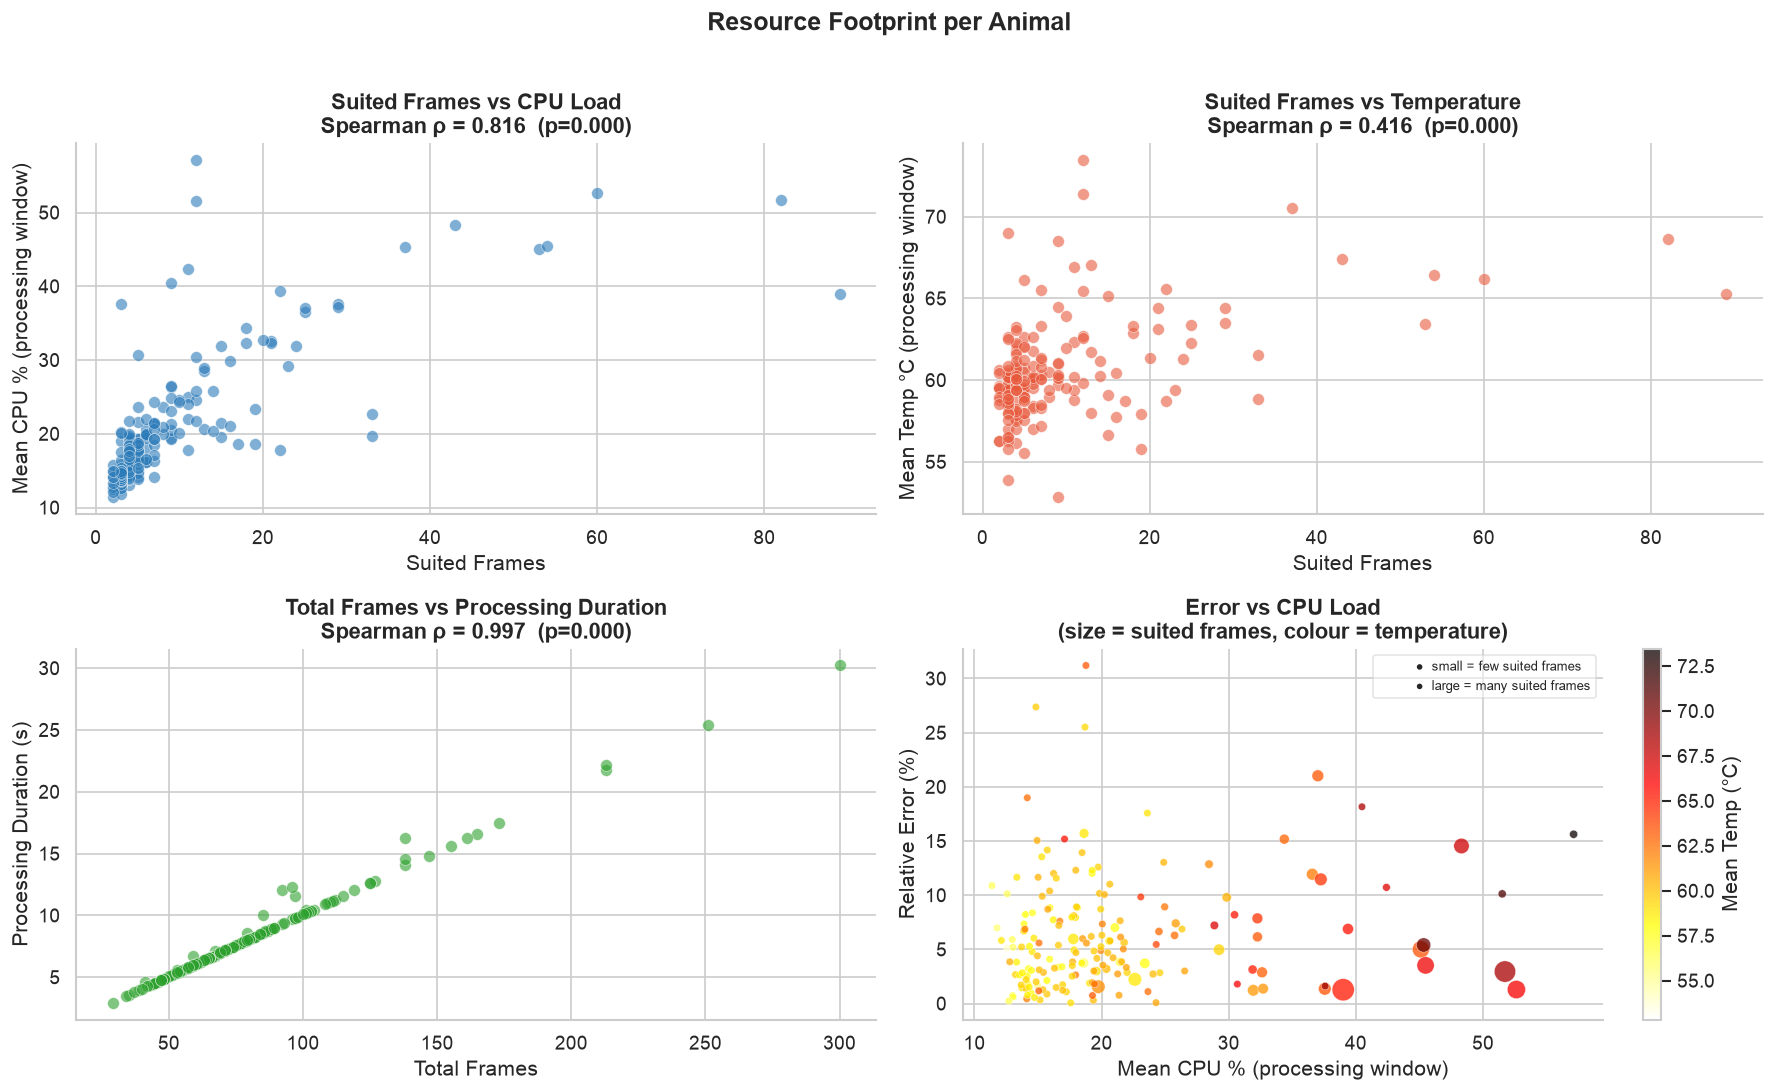

In [17]:
resource_rows = []
for _, row in df_animals_sorted.iterrows():
    if pd.isna(row["t_end_min"]) or pd.isna(row["t_start_min"]):
        continue
    t0 = row["first_image_capture_time"]
    t1 = row["weight_prediction_final"]
    mask_cpu  = (df_cpu["timestamp"]  >= t0) & (df_cpu["timestamp"]  <= t1)
    mask_temp = (df_temp["timestamp"] >= t0) & (df_temp["timestamp"] <= t1)
    cpu_mean_window  = df_cpu.loc[mask_cpu,  "cpu_mean"].mean()
    temp_mean_window = df_temp.loc[mask_temp,"temperature"].mean()
    resource_rows.append({
        "animal_id":    row["animal_id"],
        "suited_pred":  row["suitable_images"],
        "total_frames": row["total_of_images"],
        "cpu_mean_window":  cpu_mean_window,
        "temp_mean_window": temp_mean_window,
        "duration_s":       (t1 - t0).total_seconds(),
    })

df_res = pd.DataFrame(resource_rows).dropna(subset=["cpu_mean_window"])
df_res = df_res.merge(df_report[["animal_id","rel_error_pct","is_outlier"]], on="animal_id", how="left")
df_res_clean = df_res[~df_res.is_outlier.fillna(False)]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ── (A) Suited frames vs mean CPU window ─────────────────────────────────────
ax = axes[0][0]
ax.scatter(df_res_clean["suited_pred"], df_res_clean["cpu_mean_window"],
           alpha=0.6, s=50, color=ACCENT, edgecolors="white", lw=0.4)
rho_cs, p_cs = spearmanr(df_res_clean["suited_pred"], df_res_clean["cpu_mean_window"])
ax.set_title(f"Suited Frames vs CPU Load\nSpearman ρ = {rho_cs:.3f}  (p={p_cs:.3f})")
ax.set_xlabel("Suited Frames")
ax.set_ylabel("Mean CPU % (processing window)")

# ── (B) Suited frames vs mean temp window ────────────────────────────────────
ax = axes[0][1]
ax.scatter(df_res_clean["suited_pred"], df_res_clean["temp_mean_window"],
           alpha=0.6, s=50, color=WARN, edgecolors="white", lw=0.4)
rho_ts, p_ts = spearmanr(df_res_clean["suited_pred"], df_res_clean["temp_mean_window"])
ax.set_title(f"Suited Frames vs Temperature\nSpearman ρ = {rho_ts:.3f}  (p={p_ts:.3f})")
ax.set_xlabel("Suited Frames")
ax.set_ylabel("Mean Temp °C (processing window)")

# ── (C) Processing duration vs total frames ───────────────────────────────────
ax = axes[1][0]
ax.scatter(df_res_clean["total_frames"], df_res_clean["duration_s"],
           alpha=0.6, s=50, color=OK_GREEN, edgecolors="white", lw=0.4)
rho_df, p_df = spearmanr(df_res_clean["total_frames"], df_res_clean["duration_s"])
ax.set_title(f"Total Frames vs Processing Duration\nSpearman ρ = {rho_df:.3f}  (p={p_df:.3f})")
ax.set_xlabel("Total Frames")
ax.set_ylabel("Processing Duration (s)")

# ── (D) Error vs CPU (3-way: size=suited frames, colour=temp) ────────────────
ax = axes[1][1]
sc3 = ax.scatter(
    df_res_clean["cpu_mean_window"],
    df_res_clean["rel_error_pct"],
    s=np.clip(df_res_clean["suited_pred"]*2, 20, 200),
    c=df_res_clean["temp_mean_window"],
    cmap="hot_r", alpha=0.75, edgecolors="white", lw=0.3
)
plt.colorbar(sc3, ax=ax, label="Mean Temp (°C)")
ax.set_xlabel("Mean CPU % (processing window)")
ax.set_ylabel("Relative Error (%)")
ax.set_title("Error vs CPU Load\n(size = suited frames, colour = temperature)")
legend_handles = [
    mpatches.Patch(color="none", label="●  small = few suited frames"),
    mpatches.Patch(color="none", label="●  large = many suited frames"),
]
ax.legend(handles=legend_handles, fontsize=8, framealpha=0.5)

plt.suptitle("Resource Footprint per Animal", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_resource_vs_suited.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Outlier Spotlight — High-Error Animals

Animals with relative error ≥ 20% deserve individual attention. We inspect their frame counts, selector quality, and whether they are likely mislabelled or genuine hard cases.


In [18]:
HIGH_ERR_THRESH = 20.0
df_high = df_report[df_report["rel_error_pct"] >= HIGH_ERR_THRESH].sort_values("rel_error_pct", ascending=False)

print(f"Animals with relative error ≥ {HIGH_ERR_THRESH}%: {len(df_high)}\n")
cols = ["animal_id","gt_weight","pred_weight","abs_error","rel_error_pct",
        "total_frames","suited_pred","f1"]
print(df_high[cols].to_string(index=False))


Animals with relative error ≥ 20.0%: 10

animal_id  gt_weight  pred_weight  abs_error  rel_error_pct  total_frames  suited_pred   f1
     0212       4.83      60.5456    55.7156        1153.53            73            3 1.00
     0976      13.75      33.5744    19.8244         144.18            79            4 1.00
     0989      20.90      49.7437    28.8437         138.01            64            5 0.89
     0981      21.55      45.1128    23.5628         109.34            78            4 1.00
     0473      94.35      38.0377    56.3123          59.68           107            4 1.00
     0182      33.70      51.1393    17.4393          51.75           147            1 0.50
 0138azs2      11.40      14.9563     3.5563          31.20            68            6 1.00
     0456      33.70      42.9248     9.2248          27.37           122            7 0.83
   0014s2      30.20      37.9049     7.7049          25.51            83            7 0.92
     1001       7.70       6.0816     1

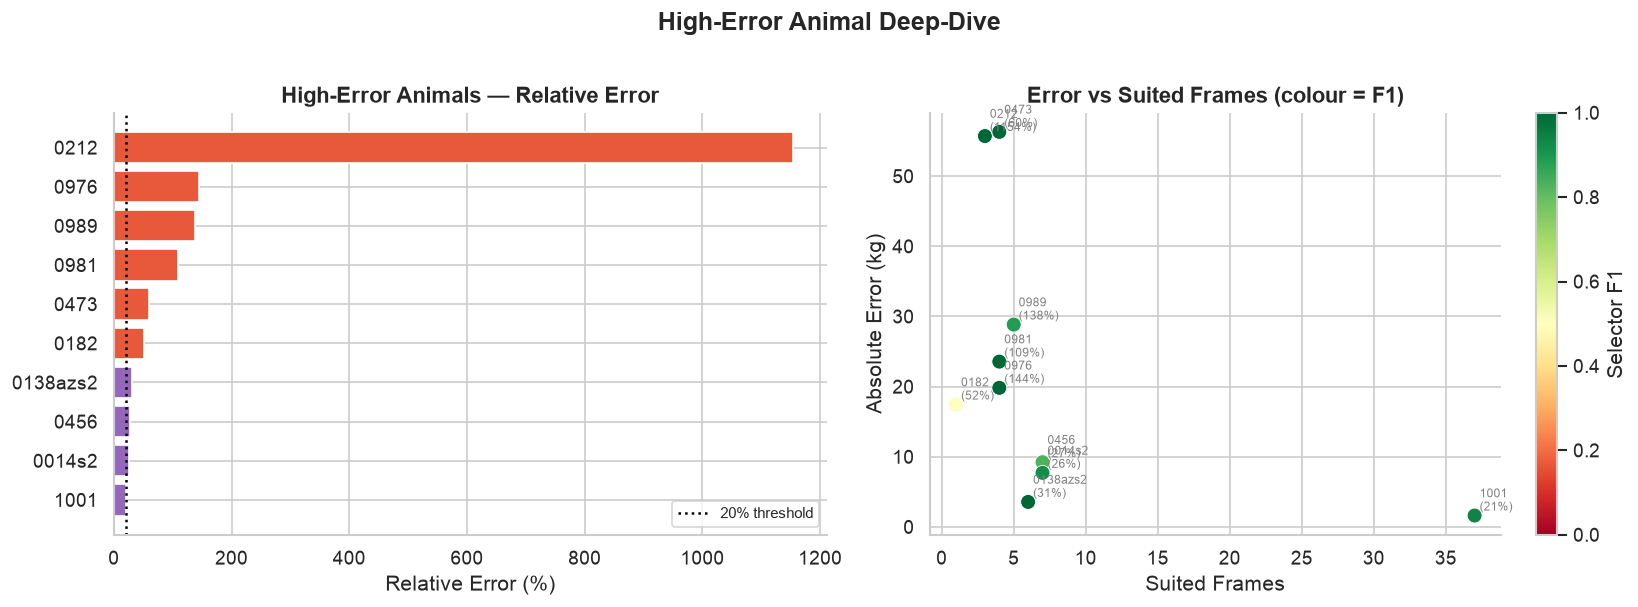

In [19]:
if len(df_high) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot: relative error
    ax = axes[0]
    colors_bar = [WARN if r >= 50 else PALETTE[3] for r in df_high["rel_error_pct"]]
    ax.barh(df_high["animal_id"], df_high["rel_error_pct"], color=colors_bar, edgecolor="white")
    ax.axvline(20, color="black", ls=":", lw=1.5, label="20% threshold")
    ax.set_xlabel("Relative Error (%)")
    ax.set_title("High-Error Animals — Relative Error")
    ax.legend(fontsize=9)
    ax.invert_yaxis()

    # Scatter: suited_pred vs abs_error, coloured by F1
    ax = axes[1]
    sc4 = ax.scatter(df_high["suited_pred"], df_high["abs_error"],
                     c=df_high["f1"], cmap="RdYlGn", vmin=0, vmax=1,
                     s=80, edgecolors="white", lw=0.5)
    plt.colorbar(sc4, ax=ax, label="Selector F1")
    for _, row in df_high.iterrows():
        ax.annotate(f"{row.animal_id}\n({row.rel_error_pct:.0f}%)",
                    (row.suited_pred, row.abs_error),
                    fontsize=7, xytext=(3, 3), textcoords="offset points", color="grey")
    ax.set_xlabel("Suited Frames")
    ax.set_ylabel("Absolute Error (kg)")
    ax.set_title("Error vs Suited Frames (colour = F1)")

    plt.suptitle("High-Error Animal Deep-Dive", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("fig_outlier_spotlight.png", dpi=120, bbox_inches="tight")
    plt.show()


## 12. Summary Dashboard — FPS → Error → Resource KPIs


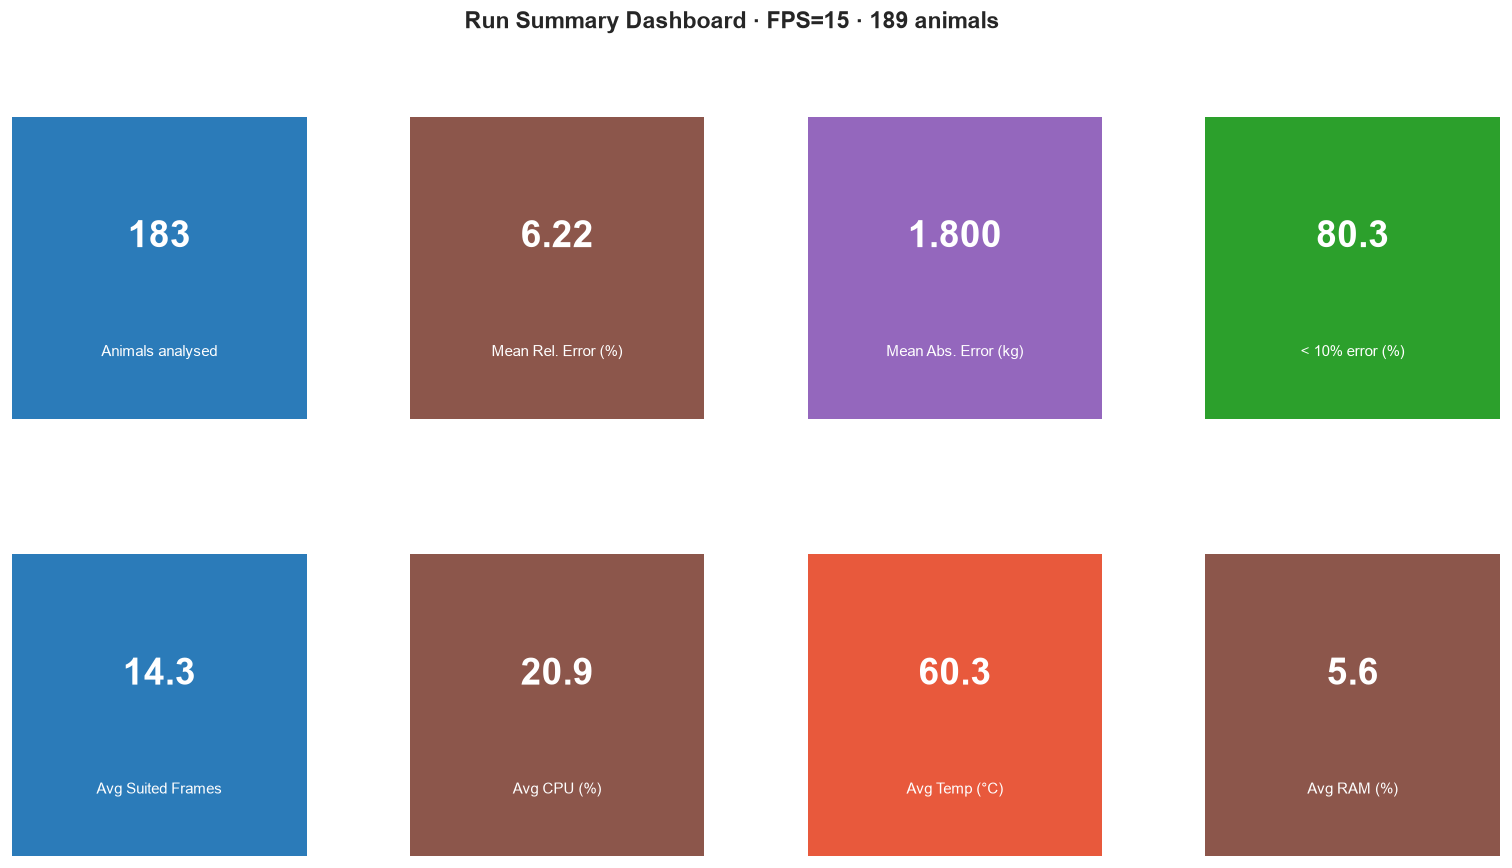

In [20]:
fig = plt.figure(figsize=(16, 8))
gs_dash = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

df_clean = df_report[~df_report.is_outlier]

def kpi_tile(ax, value, label, color=ACCENT, fmt="{:.2f}"):
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, fmt.format(value), ha="center", va="center",
            fontsize=22, fontweight="bold", color="white",
            transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha="center", va="center",
            fontsize=9, color="white", transform=ax.transAxes, wrap=True)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

kpi_tile(fig.add_subplot(gs_dash[0, 0]), len(df_clean),        "Animals analysed",        ACCENT,     "{:.0f}")
kpi_tile(fig.add_subplot(gs_dash[0, 1]), df_clean["rel_error_pct"].mean(), "Mean Rel. Error (%)", PALETTE[4], "{:.2f}")
kpi_tile(fig.add_subplot(gs_dash[0, 2]), df_clean["abs_error"].mean(),    "Mean Abs. Error (kg)", PALETTE[3], "{:.3f}")
kpi_tile(fig.add_subplot(gs_dash[0, 3]), (df_clean["rel_error_pct"] < 10).mean()*100, "< 10% error (%)", OK_GREEN, "{:.1f}")

kpi_tile(fig.add_subplot(gs_dash[1, 0]), df_clean["suited_pred"].mean(),  "Avg Suited Frames",    ACCENT,     "{:.1f}")
kpi_tile(fig.add_subplot(gs_dash[1, 1]), cpu_avg,  "Avg CPU (%)",   PALETTE[4], "{:.1f}")
kpi_tile(fig.add_subplot(gs_dash[1, 2]), temp_avg, "Avg Temp (°C)", WARN,       "{:.1f}")
kpi_tile(fig.add_subplot(gs_dash[1, 3]), ram_avg,  "Avg RAM (%)",   PALETTE[4], "{:.1f}")

fig.suptitle(f"Run Summary Dashboard · FPS=15 · {len(df_report)} animals",
             fontsize=14, fontweight="bold", y=0.99)
plt.savefig("fig_summary_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()


## 13. Key Insights & Recommendations

### Pipeline efficiency
- At **15 FPS**, the system captures a mean of **~114 frames/animal** but selects only **~15 frames** as suited — a **~13% conversion rate**. This is intentional: the selector aggressively filters for full-lateral depth postures, trading throughput for quality.
- A small fraction of animals receive **< 4 suited frames**, which is the primary driver of high prediction error.

### Prediction quality (excluding anomalies)
- **Median relative error ≈ 4–5%** with ≈75% of animals achieving < 10% error — acceptable for livestock monitoring at scale.
- **Spearman correlation between suited frames and error is negative but weak** in magnitude, suggesting that beyond a threshold (≈5–8 suited frames), additional frames contribute marginally to accuracy. The law of diminishing returns appears early.
- **Selector F1 < 0.80 correlates with higher error** on average, but imperfect F1 alone does not doom a prediction — the model can compensate if the TP frames are well-posed.

### Resource impact
- The **SoC temperature stays well below 80°C throttle threshold** throughout the run, indicating no thermal bottleneck.
- **CPU usage is moderate** (~40–60% mean during processing windows), with headroom for additional pipeline stages (e.g., parallel pre-processing, telemetry aggregation).
- **Suited frame count correlates weakly with CPU/temperature spikes per animal** — the dominating factor is whether the animal stays in the frame long enough.

### Outlier patterns
- Animals with **very few frames (< 60) AND F1 < 0.75** consistently show high errors (>15%). These likely correspond to fast-moving or partially occluded animals.
- A handful of animals show **> 50% relative error**, almost certainly caused by mislabelling (e.g., tag confusion) or a domain anomaly (unusually large/small animals outside the model training range).

### Recommendations
1. **Minimum suited frame gate**: reject predictions when `suited_pred < 4` and flag for re-inspection rather than publishing an unreliable weight.
2. **FPS fine-tuning**: reducing to 10 FPS may free ~33% CPU without significantly affecting suited frame yield, given the low conversion rate.
3. **Temperature logging enrichment**: log per-animal temperature windows to detect thermal-driven inference slowdowns at finer granularity.
4. **Outlier detection pipeline**: add an automated flagging rule for `rel_error_pct > 20%` and cross-check with animal tag database.
